# Analysis of X versus MNE



In [15]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple, Optional
import numpy as np

In [65]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict, Tuple, Callable, Optional, Sequence
import numpy as np
from scipy.interpolate import RegularGridInterpolator


# ============================================================
# 1. REGIMES
# ============================================================

REGIMES_X_HF = ("X", "HF")


@dataclass(frozen=True)
class RegimeConfig:
    active_modes: Tuple[str, ...] = REGIMES_X_HF

    def __post_init__(self) -> None:
        allowed = {"D", "X", "HF", "EXIT"}
        invalid = [m for m in self.active_modes if m not in allowed]
        if invalid:
            raise ValueError(f"Invalid regimes: {invalid}")

    @property
    def mode_to_index(self) -> Dict[str, int]:
        return {m: i for i, m in enumerate(self.active_modes)}

    @property
    def index_to_mode(self) -> Dict[int, str]:
        return {i: m for i, m in enumerate(self.active_modes)}

    def has_mode(self, mode: str) -> bool:
        return mode in self.active_modes


# ============================================================
# 2. PARAMETERS
# ============================================================

@dataclass
class ModelParams:
    # Dynamic
    beta: float = 0.95
    delta: float = 0.10
    phi_H: float = 2.0
    phi_F: float = 2.0
    xi_H: float = 0.40
    xi_F: float = 0.40

    # Marginal return of investment 
    q_H: float = 0.6
    q_F: float = 0.6

    # CES / reduced-form parameters
    sigma: float = 5.0
    alpha: float = 0.30

    # Productivity / demand / cost
    A_H: float = 1.0
    A_F: float = 1.0
    Lambda_H: float = 1.0
    Lambda_F: float = 1.2
    w_H: float = 1.0
    w_F: float = 1.0
    tau_X: float = 1.15

    # Fixed operating costs
    f_H_op: float = 0.03
    f_X_op: float = 0.015
    f_F_op: float = 0.03

    # Sunk regime-switching costs
    f_X_E: float = 0.10
    f_F_E: float = 0.05
    f_scope: float = 0.10

    # Extension toggle
    use_M: bool = False

    # Optional technology-capital parameters for later
    phi_M: float = 2.0
    xi_M: float = 0.0
    alpha_M: float = 0.0

    eps: float = 1e-10

    @property
    def a(self) -> float:
        return (self.sigma - 1.0) / self.sigma

    @property
    def gamma(self) -> float:
        return 1.0 - self.alpha

    @property
    def mu(self) -> float:
        val = 1.0 - self.a * self.gamma
        if val <= 0:
            raise ValueError("Need mu = 1 - a*gamma > 0.")
        return val

    @property
    def rho(self) -> float:
        return self.a / self.mu

    @property
    def kappa(self) -> float:
        return self.alpha * self.rho


# ============================================================
# 3. STATE
# ============================================================

@dataclass
class FirmState:
    KH: float
    KF: float
    s_idx: int
    prev_mode: str
    M: float = 0.0


# ============================================================
# 4. TRANSITIONS AND COSTS
# ============================================================

def investment_cost(i: float, phi: float, q: float = 1.0) -> float:
    return q * i + 0.5 * phi * i**2


def next_capital(K: float, i: float, delta: float) -> float:
    return (1.0 - delta) * K + i


def switching_cost(prev_mode: str, new_mode: str, p: ModelParams) -> float:
    if prev_mode == new_mode:
        return 0.0

    # X -> HF upgrade
    if prev_mode == "X" and new_mode == "HF":
        return p.f_F_E + p.f_scope

    # Reserved for later if D is added
    if prev_mode == "D" and new_mode == "X":
        return p.f_X_E
    if prev_mode == "D" and new_mode == "HF":
        return p.f_X_E + p.f_F_E + p.f_scope

    return 0.0


# ============================================================
# 5. PRODUCTIVITY PROCESS
# ============================================================

def rouwenhorst(n: int, rho: float, sigma_eps: float, mu: float = 0.0) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if n < 2:
        raise ValueError("n must be at least 2.")
    if abs(rho) >= 1.0:
        raise ValueError("Need |rho| < 1 for a stationary AR(1).")

    prob = (1.0 + rho) / 2.0
    P = np.array([[1.0]])

    for m in range(2, n + 1):
        P_new = np.zeros((m, m))
        P_new[:-1, :-1] += prob * P
        P_new[:-1, 1:] += (1.0 - prob) * P
        P_new[1:, :-1] += (1.0 - prob) * P
        P_new[1:, 1:] += prob * P
        P_new[1:-1, :] /= 2.0
        P = P_new

    sigma_z = sigma_eps / np.sqrt(1.0 - rho**2)
    psi = sigma_z * np.sqrt(n - 1)
    z_grid = np.linspace(-psi, psi, n) + mu
    s_grid = np.exp(z_grid)
    return z_grid, s_grid, P


def draw_initial_productivity_indices(
    probs: np.ndarray,
    n_firms: int,
    seed: int | None = None,
) -> np.ndarray:
    probs = np.asarray(probs, dtype=float)
    probs = probs / probs.sum()
    rng = np.random.default_rng(seed)
    idx = np.arange(len(probs))
    return rng.choice(idx, size=n_firms, p=probs)


# ============================================================
# 6. PROFIT BLOCK
# ============================================================

def _safe_power(x: float, power: float, eps: float) -> float:
    return max(x, eps) ** power


def omega_H(p: ModelParams) -> float:
    Rbar_H = p.Lambda_H * ((p.a * p.gamma * p.Lambda_H) / p.w_H) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_H * (p.A_H ** p.rho)


def omega_F(p: ModelParams) -> float:
    Rbar_F = p.Lambda_F * ((p.a * p.gamma * p.Lambda_F) / p.w_F) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_F * (p.A_F ** p.rho)


def omega_X(p: ModelParams) -> float:
    chi_X = (p.Lambda_F / (p.tau_X * p.Lambda_H)) ** p.sigma
    Xi_X = p.Lambda_H + p.Lambda_F * (chi_X ** p.a)
    w_X_eff = p.w_H * (1.0 + p.tau_X * chi_X) ** (1.0 / p.gamma)
    Rbar_X = Xi_X * ((p.a * p.gamma * Xi_X) / w_X_eff) ** (p.a * p.gamma / p.mu)
    return p.mu * Rbar_X * (p.A_H ** p.rho)


def tech_multiplier(KH: float, KF: float, M: float, mode: str, p: ModelParams) -> float:
    """
    Benchmark:
        no technology capital => multiplier = 1
    Later:
        allow M to enter here without changing dynamic code.
    """
    if not p.use_M:
        return 1.0
    return max(M, p.eps) ** p.alpha_M


def profit_X(KH: float, s: float, M: float, p: ModelParams) -> float:
    mult = tech_multiplier(KH=KH, KF=0.0, M=M, mode="X", p=p)
    return omega_X(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) * mult - p.f_H_op - p.f_X_op


def profit_HF(KH: float, KF: float, s: float, M: float, p: ModelParams) -> float:
    mult = tech_multiplier(KH=KH, KF=KF, M=M, mode="HF", p=p)
    home = omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho)
    foreign = omega_F(p) * _safe_power(KF, p.kappa, p.eps) * (s ** p.rho)
    return (home + foreign) * mult - p.f_H_op - p.f_F_op


def flow_profit(mode: str, KH: float, KF: float, s: float, M: float, p: ModelParams) -> float:
    if mode == "X":
        return profit_X(KH, s, M, p)
    if mode == "HF":
        return profit_HF(KH, KF, s, M, p)
    if mode == "D":
        return omega_H(p) * _safe_power(KH, p.kappa, p.eps) * (s ** p.rho) - p.f_H_op
    raise ValueError(f"Unknown mode: {mode}")


# ============================================================
# 7. TERMINAL VALUE
# ============================================================

def terminal_value(KH: float, KF: float, M: float, p: ModelParams) -> float:
    return p.xi_H * KH + p.xi_F * KF + p.xi_M * M


# ============================================================
# 8. INTERPOLATION HELPERS
# ============================================================

def _clip(x: float, grid: np.ndarray) -> float:
    return float(np.clip(x, grid[0], grid[-1]))


def build_value_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    V: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    for pm, prev_mode in enumerate(cfg.active_modes):
        for k in range(len(s_grid)):
            interps[(prev_mode, k)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                V[pm, :, :, k],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def value_obj(prev_mode: str, KH: float, KF: float, s_idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, s_idx)](np.array([[KHc, KFc]]))[0])
    return value_obj


# ============================================================
# 8B. PRECOMPUTED EXPECTED CONTINUATION OBJECTS
# ============================================================

def build_expected_grid_from_markov(
    V_next: np.ndarray,
    P: np.ndarray,
    beta: float,
) -> np.ndarray:
    """
    Precompute beta * E[V_next | current s].

    V_next shape: (n_prev_mode, n_KH, n_KF, n_s_next)
    Returns:
        EV shape: (n_prev_mode, n_KH, n_KF, n_s_current)
    """
    n_prev, n_KH, n_KF, n_s_next = V_next.shape
    n_s_cur = P.shape[0]

    EV = np.empty((n_prev, n_KH, n_KF, n_s_cur))
    for pm in range(n_prev):
        for s_cur in range(n_s_cur):
            EV[pm, :, :, s_cur] = beta * np.tensordot(
                V_next[pm, :, :, :],
                P[s_cur, :],
                axes=([2], [0]),
            )
    return EV


def build_expected_interpolators(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    EV: np.ndarray,
    cfg: RegimeConfig,
) -> Dict[Tuple[str, int], RegularGridInterpolator]:
    interps: Dict[Tuple[str, int], RegularGridInterpolator] = {}
    n_index = EV.shape[3]

    for pm, prev_mode in enumerate(cfg.active_modes):
        for idx in range(n_index):
            interps[(prev_mode, idx)] = RegularGridInterpolator(
                (KH_grid, KF_grid),
                EV[pm, :, :, idx],
                bounds_error=False,
                fill_value=None,
            )
    return interps


def make_expected_value_callable(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    interps: Dict[Tuple[str, int], RegularGridInterpolator],
) -> Callable[[str, float, float, int], float]:
    def EV_obj(prev_mode: str, KH: float, KF: float, idx: int) -> float:
        KHc = _clip(KH, KH_grid)
        KFc = _clip(KF, KF_grid)
        return float(interps[(prev_mode, idx)](np.array([[KHc, KFc]]))[0])

    return EV_obj


# ============================================================
# 9. PERIOD-2
# ============================================================

def branch_value_t2(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
    iH: float,
    iF: float,
    M: float = 0.0,
) -> Dict[str, float]:
    KH3 = next_capital(KH, iH, p.delta)
    KF3 = next_capital(KF, iF, p.delta)

    pi = flow_profit(mode, KH, KF, s, M, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(iH, p.phi_H) + investment_cost(iF, p.phi_F)
    cont = p.beta * terminal_value(KH3, KF3, M, p)

    value = pi - switch - adjust + cont

    return {
        "mode": mode,
        "value": value,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "KH_next": KH3,
        "KF_next": KF3,
        "continuation": cont,
    }


def solve_period2_branch(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s: float,
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, float]:
    iH_max = max(KH_grid[-1] - (1.0 - p.delta) * KH, 0.0)
    iF_max = max(KF_grid[-1] - (1.0 - p.delta) * KF, 0.0)

    if mode in ("X", "D"):
        iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
        best: Optional[Dict[str, float]] = None
        best_val = -np.inf

        for iH in iH_candidates:
            out = branch_value_t2(
                mode=mode,
                prev_mode=prev_mode,
                KH=KH,
                KF=KF,
                s=s,
                p=p,
                iH=float(iH),
                iF=0.0,
            )
            if out["value"] > best_val:
                best_val = out["value"]
                best = out

        assert best is not None
        return best

    if mode == "HF":
        iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
        iF_candidates = np.linspace(0.0, iF_max, n_search_iF)
        best: Optional[Dict[str, float]] = None
        best_val = -np.inf

        for iH in iH_candidates:
            for iF in iF_candidates:
                out = branch_value_t2(
                    mode=mode,
                    prev_mode=prev_mode,
                    KH=KH,
                    KF=KF,
                    s=s,
                    p=p,
                    iH=float(iH),
                    iF=float(iF),
                )
                if out["value"] > best_val:
                    best_val = out["value"]
                    best = out

        assert best is not None
        return best

    raise ValueError(f"Unknown mode: {mode}")


def solve_period2_state(
    KH: float,
    KF: float,
    s: float,
    prev_mode: str,
    p: ModelParams,
    cfg: RegimeConfig,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, object]:
    branches = {
        mode: solve_period2_branch(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH,
            KF=KF,
            s=s,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            n_search_iH=n_search_iH,
            n_search_iF=n_search_iF,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period2_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    p: ModelParams,
    cfg: RegimeConfig,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, np.ndarray]:
    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V2 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, s in enumerate(s_grid):
                    sol = solve_period2_state(
                        KH=KH,
                        KF=KF,
                        s=s,
                        prev_mode=prev_mode,
                        p=p,
                        cfg=cfg,
                        KH_grid=KH_grid,
                        KF_grid=KF_grid,
                        n_search_iH=n_search_iH,
                        n_search_iF=n_search_iF,
                    )
                    best = sol["best"]
                    V2[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]

    V2_interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V2, cfg)
    V2_obj = make_value_callable(KH_grid, KF_grid, V2_interps)

    return {
        "V2": V2,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "interpolators": V2_interps,
        "value_callable": V2_obj,
    }


# ============================================================
# 10. PERIOD-1
# ============================================================

def branch_value_t1(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s1_idx: int,
    s_grid: np.ndarray,
    EV2_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    iH: float,
    iF: float,
    M: float = 0.0,
) -> Dict[str, float]:
    """
    Period-1 branch value using a precomputed continuation object:
        EV2_obj(mode, KH2, KF2, s1_idx) = beta * E[V2 | s1_idx, mode]
    """
    s = float(s_grid[s1_idx])

    KH2 = next_capital(KH, iH, p.delta)
    KF2 = next_capital(KF, iF, p.delta)

    pi = flow_profit(mode, KH, KF, s, M, p)
    switch = switching_cost(prev_mode, mode, p)
    adjust = investment_cost(iH, p.phi_H, p.q_H) + investment_cost(iF, p.phi_F, p.q_F)
    EV2 = EV2_obj(mode, KH2, KF2, s1_idx)

    value = pi - switch - adjust + EV2

    return {
        "mode": mode,
        "value": value,
        "profit": pi,
        "switch_cost": switch,
        "iH": iH,
        "iF": iF,
        "KH_next": KH2,
        "KF_next": KF2,
        "EV2": EV2,
    }


def solve_period1_branch(
    mode: str,
    prev_mode: str,
    KH: float,
    KF: float,
    s1_idx: int,
    s_grid: np.ndarray,
    EV2_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, float]:
    iH_max = max(KH_grid[-1] - (1.0 - p.delta) * KH, 0.0)
    iF_max = max(KF_grid[-1] - (1.0 - p.delta) * KF, 0.0)

    if mode in ("X", "D"):
        iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
        best: Optional[Dict[str, float]] = None
        best_val = -np.inf
        for iH in iH_candidates:
            out = branch_value_t1(
                mode=mode,
                prev_mode=prev_mode,
                KH=KH,
                KF=KF,
                s1_idx=s1_idx,
                s_grid=s_grid,
                EV2_obj=EV2_obj,
                p=p,
                iH=float(iH),
                iF=0.0,
            )
            if out["value"] > best_val:
                best_val = out["value"]
                best = out
        assert best is not None
        return best

    if mode == "HF":
        iH_candidates = np.linspace(0.0, iH_max, n_search_iH)
        iF_candidates = np.linspace(0.0, iF_max, n_search_iF)
        best: Optional[Dict[str, float]] = None
        best_val = -np.inf
        for iH in iH_candidates:
            for iF in iF_candidates:
                out = branch_value_t1(
                    mode=mode,
                    prev_mode=prev_mode,
                    KH=KH,
                    KF=KF,
                    s1_idx=s1_idx,
                    s_grid=s_grid,
                    EV2_obj=EV2_obj,
                    p=p,
                    iH=float(iH),
                    iF=float(iF),
                )
                if out["value"] > best_val:
                    best_val = out["value"]
                    best = out
        assert best is not None
        return best

    raise ValueError(f"Unknown mode: {mode}")


def solve_period1_state(
    KH1: float,
    KF1: float,
    s1_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    EV2_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    cfg: RegimeConfig,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, object]:
    branches = {
        mode: solve_period1_branch(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH1,
            KF=KF1,
            s1_idx=s1_idx,
            s_grid=s_grid,
            EV2_obj=EV2_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            n_search_iH=n_search_iH,
            n_search_iF=n_search_iF,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period1_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period2_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, np.ndarray]:
    V2_value_obj = period2_sol["value_callable"]

    # Precompute beta * E[V2 | s1, mode]
    EV2_grid = build_expected_grid_from_markov(
        V_next=period2_sol["V2"],
        P=P,
        beta=p.beta,
    )
    EV2_interps = build_expected_interpolators(KH_grid, KF_grid, EV2_grid, cfg)
    EV2_obj = make_expected_value_callable(KH_grid, KF_grid, EV2_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V1 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, _ in enumerate(s_grid):
                    sol = solve_period1_state(
                        KH1=KH,
                        KF1=KF,
                        s1_idx=k,
                        prev_mode=prev_mode,
                        s_grid=s_grid,
                        EV2_obj=EV2_obj,
                        p=p,
                        KH_grid=KH_grid,
                        KF_grid=KF_grid,
                        cfg=cfg,
                        n_search_iH=n_search_iH,
                        n_search_iF=n_search_iF,
                    )
                    best = sol["best"]
                    V1[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]

    V1_interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V1, cfg)
    V1_value_obj = make_value_callable(KH_grid, KF_grid, V1_interps)

    return {
        "V1": V1,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "interpolators": V1_interps,
        "value_callable": V1_value_obj,
        "period2_value_callable": V2_value_obj,
        "period2_expected_grid": EV2_grid,
        "period2_expected_interpolators": EV2_interps,
        "period2_expected_callable": EV2_obj,
        # compatibility alias
        "period2_interpolators": EV2_obj,
    }

# ============================================================
# 10B. PERIOD-0
# ============================================================

def solve_period0_state(
    KH0: float,
    KF0: float,
    s0_idx: int,
    prev_mode: str,
    s_grid: np.ndarray,
    EV1_obj: Callable[[str, float, float, int], float],
    p: ModelParams,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    cfg: RegimeConfig,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, object]:
    branches = {
        mode: solve_period1_branch(
            mode=mode,
            prev_mode=prev_mode,
            KH=KH0,
            KF=KF0,
            s1_idx=s0_idx,
            s_grid=s_grid,
            EV2_obj=EV1_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            n_search_iH=n_search_iH,
            n_search_iF=n_search_iF,
        )
        for mode in cfg.active_modes
    }
    best_mode = max(cfg.active_modes, key=lambda m: branches[m]["value"])
    return {
        "best_mode": best_mode,
        "best": branches[best_mode],
        "all": branches,
    }


def solve_period0_grid(
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    period1_sol: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    n_search_iH: int = 15,
    n_search_iF: int = 12,
) -> Dict[str, np.ndarray]:
    V1_value_obj = period1_sol["value_callable"]

    EV1_grid = build_expected_grid_from_markov(
        V_next=period1_sol["V1"],
        P=P,
        beta=p.beta,
    )
    EV1_interps = build_expected_interpolators(KH_grid, KF_grid, EV1_grid, cfg)
    EV1_obj = make_expected_value_callable(KH_grid, KF_grid, EV1_interps)

    n_prev = len(cfg.active_modes)
    n_KH = len(KH_grid)
    n_KF = len(KF_grid)
    n_s = len(s_grid)

    V0 = np.empty((n_prev, n_KH, n_KF, n_s))
    policy_mode = np.empty((n_prev, n_KH, n_KF, n_s), dtype=int)
    iH_star = np.empty((n_prev, n_KH, n_KF, n_s))
    iF_star = np.empty((n_prev, n_KH, n_KF, n_s))

    for pm, prev_mode in enumerate(cfg.active_modes):
        for i, KH in enumerate(KH_grid):
            for j, KF in enumerate(KF_grid):
                for k, _ in enumerate(s_grid):
                    sol = solve_period0_state(
                        KH0=KH,
                        KF0=KF,
                        s0_idx=k,
                        prev_mode=prev_mode,
                        s_grid=s_grid,
                        EV1_obj=EV1_obj,
                        p=p,
                        KH_grid=KH_grid,
                        KF_grid=KF_grid,
                        cfg=cfg,
                        n_search_iH=n_search_iH,
                        n_search_iF=n_search_iF,
                    )
                    best = sol["best"]
                    V0[pm, i, j, k] = best["value"]
                    policy_mode[pm, i, j, k] = cfg.mode_to_index[sol["best_mode"]]
                    iH_star[pm, i, j, k] = best["iH"]
                    iF_star[pm, i, j, k] = best["iF"]

    V0_interps = build_value_interpolators(KH_grid, KF_grid, s_grid, V0, cfg)
    V0_value_obj = make_value_callable(KH_grid, KF_grid, V0_interps)

    return {
        "V0": V0,
        "policy_mode": policy_mode,
        "iH_star": iH_star,
        "iF_star": iF_star,
        "interpolators": V0_interps,
        "value_callable": V0_value_obj,
        "period1_value_callable": V1_value_obj,
        "period1_expected_grid": EV1_grid,
        "period1_expected_interpolators": EV1_interps,
        "period1_expected_callable": EV1_obj,
    }

# ============================================================
# 11. SIMULATION FROM INITIAL STATES
# ============================================================

def simulate_firms_from_initial_states_3periods(
    KH0_init: Sequence[float],
    KF0_init: Sequence[float],
    s0_idx_init: Sequence[int],
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    grid_sol_p0: Dict[str, np.ndarray],
    grid_sol_p1: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    seed: int = 123,
    initial_prev_mode: str = "X",
) -> Dict[str, list[dict]]:
    KH0_init = np.asarray(KH0_init, dtype=float)
    KF0_init = np.asarray(KF0_init, dtype=float)
    s0_idx_init = np.asarray(s0_idx_init, dtype=int)

    n_firms = len(KH0_init)
    if not (len(KF0_init) == len(s0_idx_init) == n_firms):
        raise ValueError("All initial-state arrays must have the same length.")

    rng = np.random.default_rng(seed)

    EV1_obj = grid_sol_p0["period1_expected_callable"]
    EV2_obj = grid_sol_p1["period2_expected_callable"]

    rows = []

    for firm_id in range(n_firms):
        KH0 = float(KH0_init[firm_id])
        KF0 = float(KF0_init[firm_id])
        s0_idx = int(s0_idx_init[firm_id])
        s0 = float(s_grid[s0_idx])

        # --------------------
        # Period 0
        # inherited regime m_{-1} = X
        # --------------------
        sol0 = solve_period0_state(
            KH0=KH0,
            KF0=KF0,
            s0_idx=s0_idx,
            prev_mode=initial_prev_mode,
            s_grid=s_grid,
            EV1_obj=EV1_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            cfg=cfg,
        )
        best0 = sol0["best"]
        mode0 = sol0["best_mode"]
        iH0 = float(best0["iH"])
        iF0 = float(best0["iF"])
        KH1 = float(best0["KH_next"])
        KF1 = float(best0["KF_next"])

        # draw productivity for period 1
        s1_idx = int(rng.choice(np.arange(len(s_grid)), p=P[s0_idx, :]))
        s1 = float(s_grid[s1_idx])

        # --------------------
        # Period 1
        # inherited regime = mode chosen in period 0
        # --------------------
        sol1 = solve_period1_state(
            KH1=KH1,
            KF1=KF1,
            s1_idx=s1_idx,
            prev_mode=mode0,
            s_grid=s_grid,
            EV2_obj=EV2_obj,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            cfg=cfg,
        )
        best1 = sol1["best"]
        mode1 = sol1["best_mode"]
        iH1 = float(best1["iH"])
        iF1 = float(best1["iF"])
        KH2 = float(best1["KH_next"])
        KF2 = float(best1["KF_next"])

        # draw productivity for period 2
        s2_idx = int(rng.choice(np.arange(len(s_grid)), p=P[s1_idx, :]))
        s2 = float(s_grid[s2_idx])

        # --------------------
        # Period 2
        # inherited regime = mode chosen in period 1
        # --------------------
        sol2 = solve_period2_state(
            KH=KH2,
            KF=KF2,
            s=s2,
            prev_mode=mode1,
            p=p,
            cfg=cfg,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
        )
        best2 = sol2["best"]
        mode2 = sol2["best_mode"]
        iH2 = float(best2["iH"])
        iF2 = float(best2["iF"])
        KH3 = float(best2["KH_next"])
        KF3 = float(best2["KF_next"])

        scrap = terminal_value(KH3, KF3, 0.0, p)

        rows.append({
            "firm_id": firm_id,

            "m_minus1": initial_prev_mode,

            "KH0": KH0,
            "KF0": KF0,
            "s0_idx": s0_idx,
            "s0": s0,
            "mode0": mode0,
            "iH0": iH0,
            "iF0": iF0,

            "KH1": KH1,
            "KF1": KF1,
            "s1_idx": s1_idx,
            "s1": s1,
            "mode1": mode1,
            "iH1": iH1,
            "iF1": iF1,

            "KH2": KH2,
            "KF2": KF2,
            "s2_idx": s2_idx,
            "s2": s2,
            "mode2": mode2,
            "iH2": iH2,
            "iF2": iF2,

            "KH3": KH3,
            "KF3": KF3,
            "scrap_value_t3": scrap,
        })

    return {"rows": rows}

# ============================================================
# 12. SMALL HELPERS
# ============================================================

def decode_mode(idx: int, cfg: RegimeConfig) -> str:
    return cfg.index_to_mode[int(idx)]



## Analysis 2

In [ ]:
# %% [markdown]
# # Structured analysis: X versus HF with 3 active decision periods

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

cfg = RegimeConfig(active_modes=("X", "HF"))
p = ModelParams()

KH_grid = np.linspace(0.10, 4.0, 50)
KF_grid = np.linspace(0.00, 2.5, 50)

z_grid, s_grid, P = rouwenhorst(n=11, rho=0.90, sigma_eps=0.12)

pm_x = cfg.mode_to_index["X"]
pm_hf = cfg.mode_to_index["HF"]

print("Active modes:", cfg.active_modes)
print("s_grid:", np.round(s_grid, 3))

grid_sol_p2 = solve_period2_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    p=p,
    cfg=cfg,
    n_search_iH=41,
    n_search_iF=31,
)

grid_sol_p1 = solve_period1_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    period2_sol=grid_sol_p2,
    p=p,
    cfg=cfg,
    n_search_iH=41,
    n_search_iF=31,
)

grid_sol_p0 = solve_period0_grid(
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    period1_sol=grid_sol_p1,
    p=p,
    cfg=cfg,
    n_search_iH=41,
    n_search_iF=31,
)

print("V2 shape:", grid_sol_p2["V2"].shape)
print("V1 shape:", grid_sol_p1["V1"].shape)
print("V0 shape:", grid_sol_p0["V0"].shape)

## Common helpers

In [67]:
# %% [markdown]
# ## Common helpers for all periods

# %%
def stationary_distribution(P: np.ndarray) -> np.ndarray:
    vals, vecs = np.linalg.eig(P.T)
    idx = np.argmin(np.abs(vals - 1.0))
    dist = np.real(vecs[:, idx])
    dist = np.maximum(dist, 0.0)
    dist = dist / dist.sum()
    return dist

def nearest_index(grid: np.ndarray, x: float) -> int:
    return int(np.abs(grid - x).argmin())

def kf_threshold_for_hf(policy_2d: np.ndarray, KF_grid: np.ndarray, hf_idx: int) -> np.ndarray:
    out = np.full(policy_2d.shape[0], np.nan)
    for i in range(policy_2d.shape[0]):
        idx = np.where(policy_2d[i, :] == hf_idx)[0]
        if len(idx) > 0:
            out[i] = KF_grid[idx[0]]
    return out

def plot_policy_map(ax, policy_2d, KH_grid, KF_grid, cfg, title):
    im = ax.imshow(
        policy_2d.T,
        origin="lower",
        aspect="auto",
        extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]],
        vmin=0,
        vmax=len(cfg.active_modes) - 1,
    )
    ax.set_xlabel("K_H")
    ax.set_ylabel("K_F")
    ax.set_title(title)
    cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(cfg.active_modes)))
    cbar.ax.set_yticklabels(cfg.active_modes)
    return im

def plot_binary_map(ax, mask_2d, KH_grid, KF_grid, title):
    im = ax.imshow(
        mask_2d.T.astype(float),
        origin="lower",
        aspect="auto",
        extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]],
        vmin=0.0,
        vmax=1.0,
    )
    ax.set_xlabel("K_H")
    ax.set_ylabel("K_F")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    return im

def period_transition_summary(sol, pm_x, pm_hf, s_grid):
    rows = []
    for k, s_val in enumerate(s_grid):
        policy_x = sol["policy_mode"][pm_x, :, :, k]
        policy_hf = sol["policy_mode"][pm_hf, :, :, k]

        stay_x = (policy_x == pm_x)
        switch_x_to_hf = (policy_x == pm_hf)
        stay_hf = (policy_hf == pm_hf)
        switch_hf_to_x = (policy_hf == pm_x)
        hysteresis = stay_x & stay_hf

        rows.append({
            "s_idx": k,
            "s": float(s_val),
            "share_X_to_X": stay_x.mean(),
            "share_X_to_HF": switch_x_to_hf.mean(),
            "share_HF_to_HF": stay_hf.mean(),
            "share_HF_to_X": switch_hf_to_x.mean(),
            "share_hysteresis": hysteresis.mean(),
            "mean_iH_prev_X": sol["iH_star"][pm_x, :, :, k].mean(),
            "mean_iF_prev_X": sol["iF_star"][pm_x, :, :, k].mean(),
            "mean_iH_prev_HF": sol["iH_star"][pm_hf, :, :, k].mean(),
            "mean_iF_prev_HF": sol["iF_star"][pm_hf, :, :, k].mean(),
        })
    return pd.DataFrame(rows)

selected_s_idx = [0, len(s_grid)//2, len(s_grid)-1]
s_idx_mid = len(s_grid)//2

print("Selected productivity states:", [round(float(s_grid[k]), 3) for k in selected_s_idx])

Selected productivity states: [0.419, 1.0, 2.388]


## Period 0

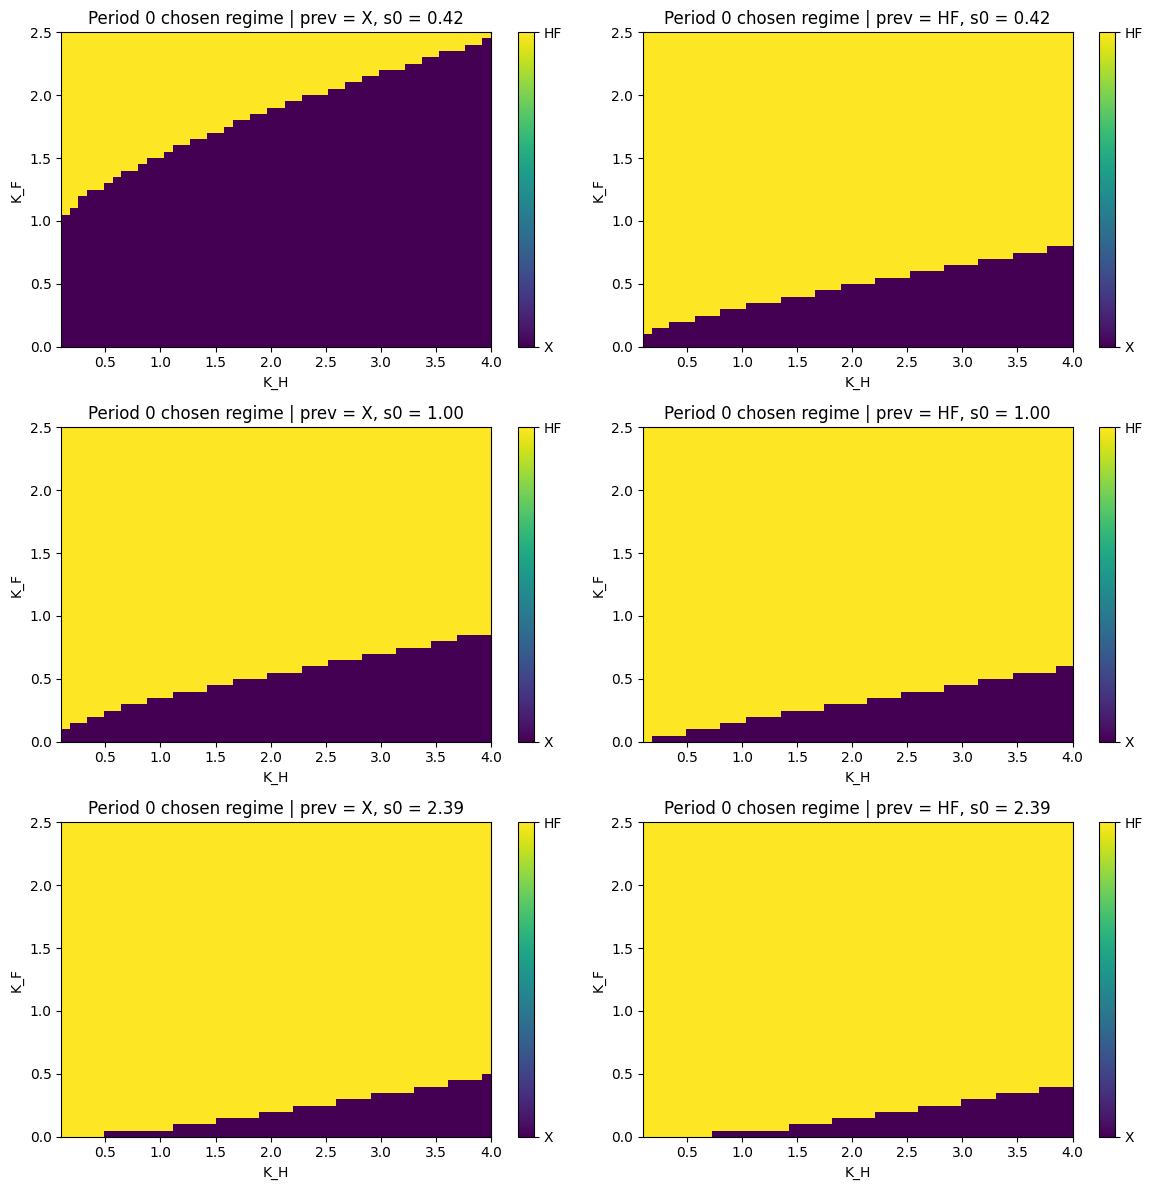

,region,share_of_grid
0,X -> X,0.2112
1,X -> HF,0.7888
2,HF -> HF,0.8740
3,HF -> X,0.1260
4,hysteresis,0.0852


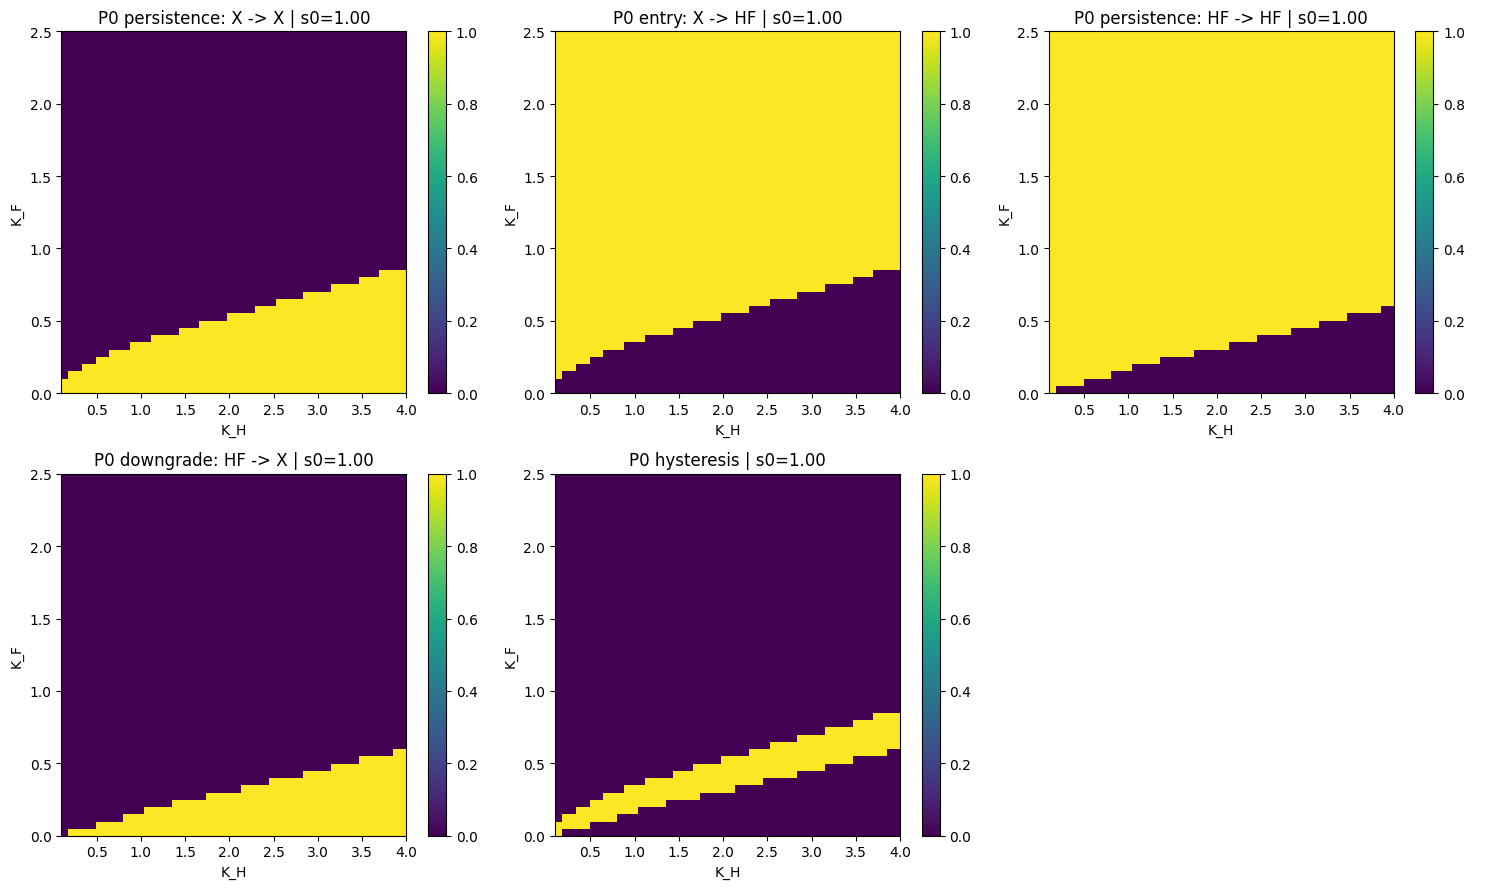

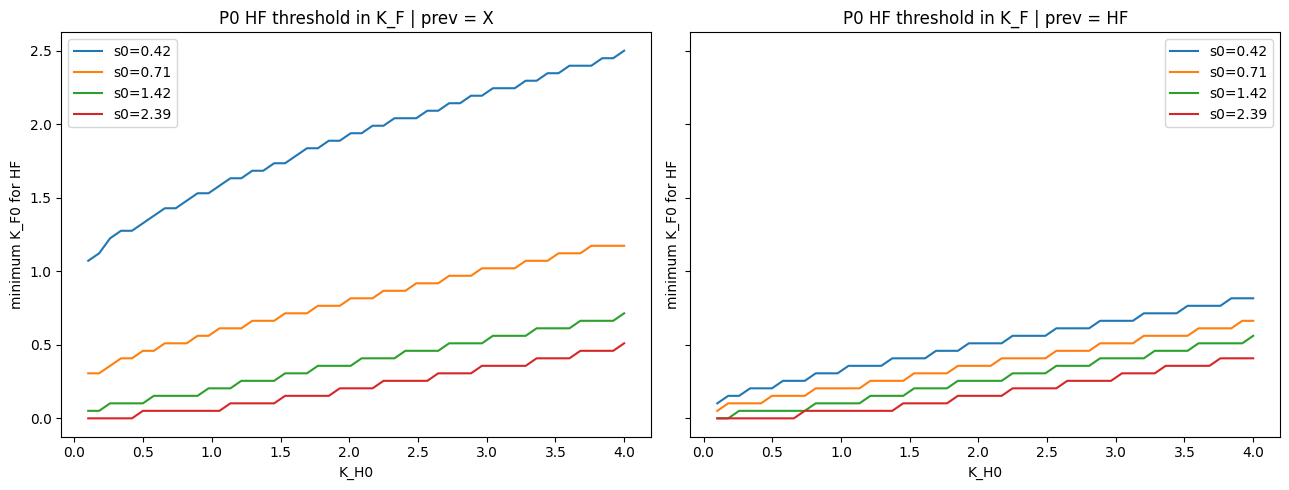

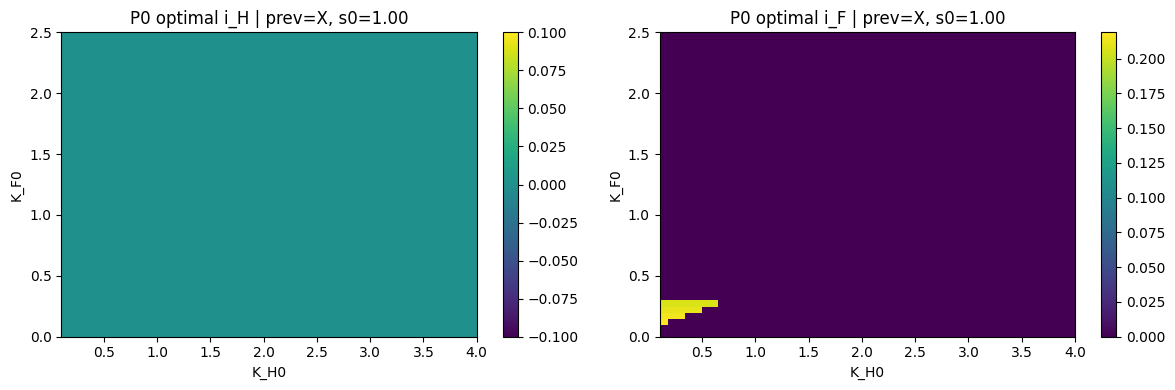

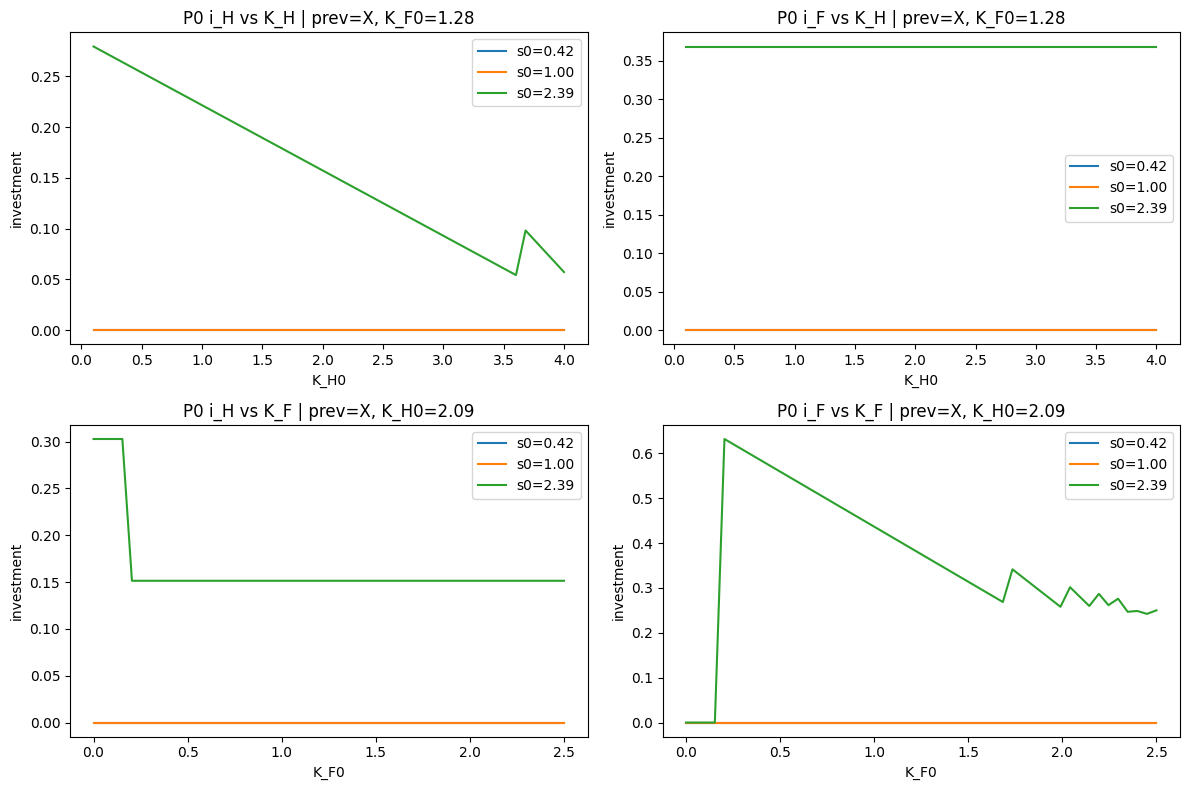

,s_idx,s,share_X_to_X,share_X_to_HF,share_HF_to_HF,share_HF_to_X,share_hysteresis,mean_iH_prev_X,mean_iF_prev_X,mean_iH_prev_HF,mean_iF_prev_HF
0,0,0.418712,0.7404,0.2596,0.8048,0.1952,0.5452,0.000000,0.000000,0.000000,0.000000
1,1,0.498348,0.5336,0.4664,0.8280,0.1720,0.3616,0.000000,0.000000,0.000000,0.000000
2,2,0.593129,0.4004,0.5996,0.8448,0.1552,0.2452,0.000000,0.000000,0.000000,0.000000
3,3,0.705937,0.3112,0.6888,0.8568,0.1432,0.1680,0.000000,0.000000,0.000000,0.000000
4,4,0.840201,0.2536,0.7464,0.8656,0.1344,0.1192,0.000000,0.000000,0.000000,0.000178
5,5,1.000000,0.2112,0.7888,0.8740,0.1260,0.0852,0.000000,0.001344,0.000000,0.005023
6,6,1.190192,0.1764,0.8236,0.8836,0.1164,0.0600,0.000869,0.022898,0.000323,0.034599
7,7,1.416556,0.1476,0.8524,0.8964,0.1036,0.0440,0.018858,0.094008,0.017600,0.102789
8,8,1.685973,0.1256,0.8744,0.9068,0.0932,0.0324,0.050205,0.120747,0.046456,0.129857
9,9,2.006631,0.1016,0.8984,0.9208,0.0792,0.0224,0.113083,0.229099,0.111155,0.238322


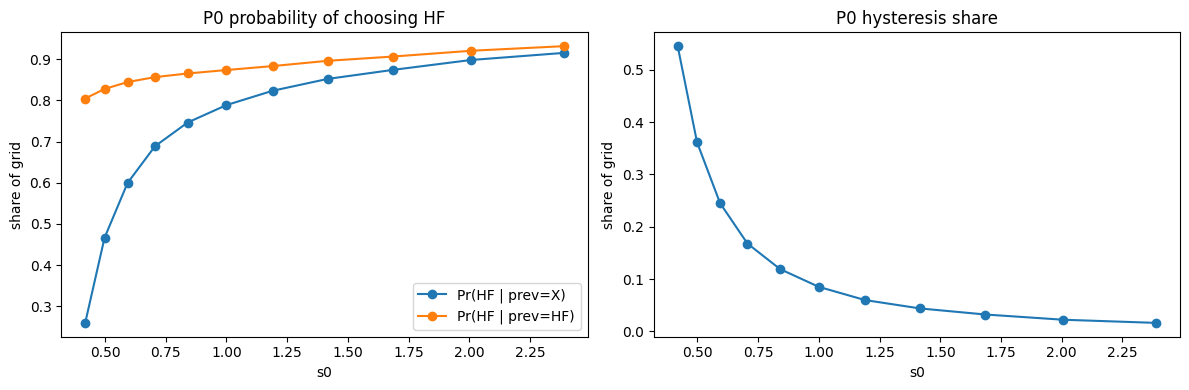

In [68]:
# %% [markdown]
# ## Period 0
# ### 2.1 Policy maps
# 
# Baseline at t=0: inherited regime is m_{-1}=X.
# We also show prev=HF as a counterfactual to visualize history dependence.

# %%
fig, axes = plt.subplots(len(selected_s_idx), 2, figsize=(12, 4 * len(selected_s_idx)))

for r, k in enumerate(selected_s_idx):
    s0_val = float(s_grid[k])

    policy0_x = grid_sol_p0["policy_mode"][pm_x, :, :, k]
    policy0_hf = grid_sol_p0["policy_mode"][pm_hf, :, :, k]

    plot_policy_map(
        axes[r, 0], policy0_x, KH_grid, KF_grid, cfg,
        title=f"Period 0 chosen regime | prev = X, s0 = {s0_val:.2f}"
    )
    plot_policy_map(
        axes[r, 1], policy0_hf, KH_grid, KF_grid, cfg,
        title=f"Period 0 chosen regime | prev = HF, s0 = {s0_val:.2f}"
    )

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 2.2 Persistence, entry, and hysteresis at period 0

# %%
s0_val_mid = float(s_grid[s_idx_mid])

policy0_x_mid = grid_sol_p0["policy_mode"][pm_x, :, :, s_idx_mid]
policy0_hf_mid = grid_sol_p0["policy_mode"][pm_hf, :, :, s_idx_mid]

stay_x0 = (policy0_x_mid == pm_x)
switch_x_to_hf0 = (policy0_x_mid == pm_hf)
stay_hf0 = (policy0_hf_mid == pm_hf)
switch_hf_to_x0 = (policy0_hf_mid == pm_x)
hysteresis0 = stay_x0 & stay_hf0

share_table_p0 = pd.DataFrame({
    "region": ["X -> X", "X -> HF", "HF -> HF", "HF -> X", "hysteresis"],
    "share_of_grid": [
        stay_x0.mean(),
        switch_x_to_hf0.mean(),
        stay_hf0.mean(),
        switch_hf_to_x0.mean(),
        hysteresis0.mean(),
    ]
})
display(share_table_p0)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_binary_map(axes[0, 0], stay_x0, KH_grid, KF_grid, f"P0 persistence: X -> X | s0={s0_val_mid:.2f}")
plot_binary_map(axes[0, 1], switch_x_to_hf0, KH_grid, KF_grid, f"P0 entry: X -> HF | s0={s0_val_mid:.2f}")
plot_binary_map(axes[0, 2], stay_hf0, KH_grid, KF_grid, f"P0 persistence: HF -> HF | s0={s0_val_mid:.2f}")
plot_binary_map(axes[1, 0], switch_hf_to_x0, KH_grid, KF_grid, f"P0 downgrade: HF -> X | s0={s0_val_mid:.2f}")
plot_binary_map(axes[1, 1], hysteresis0, KH_grid, KF_grid, f"P0 hysteresis | s0={s0_val_mid:.2f}")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 2.3 HF threshold in K_F at period 0

# %%
selected_s_idx_thr = [0, len(s_grid)//3, 2*len(s_grid)//3, len(s_grid)-1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for k in selected_s_idx_thr:
    s0_val = float(s_grid[k])

    policy0_x = grid_sol_p0["policy_mode"][pm_x, :, :, k]
    policy0_hf = grid_sol_p0["policy_mode"][pm_hf, :, :, k]

    thr_x = kf_threshold_for_hf(policy0_x, KF_grid, pm_hf)
    thr_hf = kf_threshold_for_hf(policy0_hf, KF_grid, pm_hf)

    axes[0].plot(KH_grid, thr_x, label=f"s0={s0_val:.2f}")
    axes[1].plot(KH_grid, thr_hf, label=f"s0={s0_val:.2f}")

axes[0].set_title("P0 HF threshold in K_F | prev = X")
axes[1].set_title("P0 HF threshold in K_F | prev = HF")
for ax in axes:
    ax.set_xlabel("K_H0")
    ax.set_ylabel("minimum K_F0 for HF")
    ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 2.4 Investment maps at period 0

# %%
iH0_x_mid = grid_sol_p0["iH_star"][pm_x, :, :, s_idx_mid]
iF0_x_mid = grid_sol_p0["iF_star"][pm_x, :, :, s_idx_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(
    iH0_x_mid.T, origin="lower", aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
axes[0].set_xlabel("K_H0")
axes[0].set_ylabel("K_F0")
axes[0].set_title(f"P0 optimal i_H | prev=X, s0={s0_val_mid:.2f}")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    iF0_x_mid.T, origin="lower", aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
axes[1].set_xlabel("K_H0")
axes[1].set_ylabel("K_F0")
axes[1].set_title(f"P0 optimal i_F | prev=X, s0={s0_val_mid:.2f}")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 2.5 Investment responses at period 0 along K_H and K_F slices

# %%
j_mid = len(KF_grid)//2
i_mid = len(KH_grid)//2
KF0_fixed = float(KF_grid[j_mid])
KH0_fixed = float(KH_grid[i_mid])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

for k in selected_s_idx:
    s0_val = float(s_grid[k])
    label = f"s0={s0_val:.2f}"

    axes[0, 0].plot(KH_grid, grid_sol_p0["iH_star"][pm_x, :, j_mid, k], label=label)
    axes[0, 1].plot(KH_grid, grid_sol_p0["iF_star"][pm_x, :, j_mid, k], label=label)

    axes[1, 0].plot(KF_grid, grid_sol_p0["iH_star"][pm_x, i_mid, :, k], label=label)
    axes[1, 1].plot(KF_grid, grid_sol_p0["iF_star"][pm_x, i_mid, :, k], label=label)

axes[0, 0].set_title(f"P0 i_H vs K_H | prev=X, K_F0={KF0_fixed:.2f}")
axes[0, 1].set_title(f"P0 i_F vs K_H | prev=X, K_F0={KF0_fixed:.2f}")
axes[1, 0].set_title(f"P0 i_H vs K_F | prev=X, K_H0={KH0_fixed:.2f}")
axes[1, 1].set_title(f"P0 i_F vs K_F | prev=X, K_H0={KH0_fixed:.2f}")

axes[0, 0].set_xlabel("K_H0"); axes[0, 1].set_xlabel("K_H0")
axes[1, 0].set_xlabel("K_F0"); axes[1, 1].set_xlabel("K_F0")
for ax in axes.ravel():
    ax.set_ylabel("investment")
    ax.legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 2.6 Transition shares over productivity at period 0

# %%
summary_p0 = period_transition_summary(grid_sol_p0, pm_x, pm_hf, s_grid)
display(summary_p0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary_p0["s"], summary_p0["share_X_to_HF"], marker="o", label="Pr(HF | prev=X)")
axes[0].plot(summary_p0["s"], summary_p0["share_HF_to_HF"], marker="o", label="Pr(HF | prev=HF)")
axes[0].set_xlabel("s0")
axes[0].set_ylabel("share of grid")
axes[0].set_title("P0 probability of choosing HF")
axes[0].legend()

axes[1].plot(summary_p0["s"], summary_p0["share_hysteresis"], marker="o")
axes[1].set_xlabel("s0")
axes[1].set_ylabel("share of grid")
axes[1].set_title("P0 hysteresis share")

plt.tight_layout()
plt.show()

## Period 1

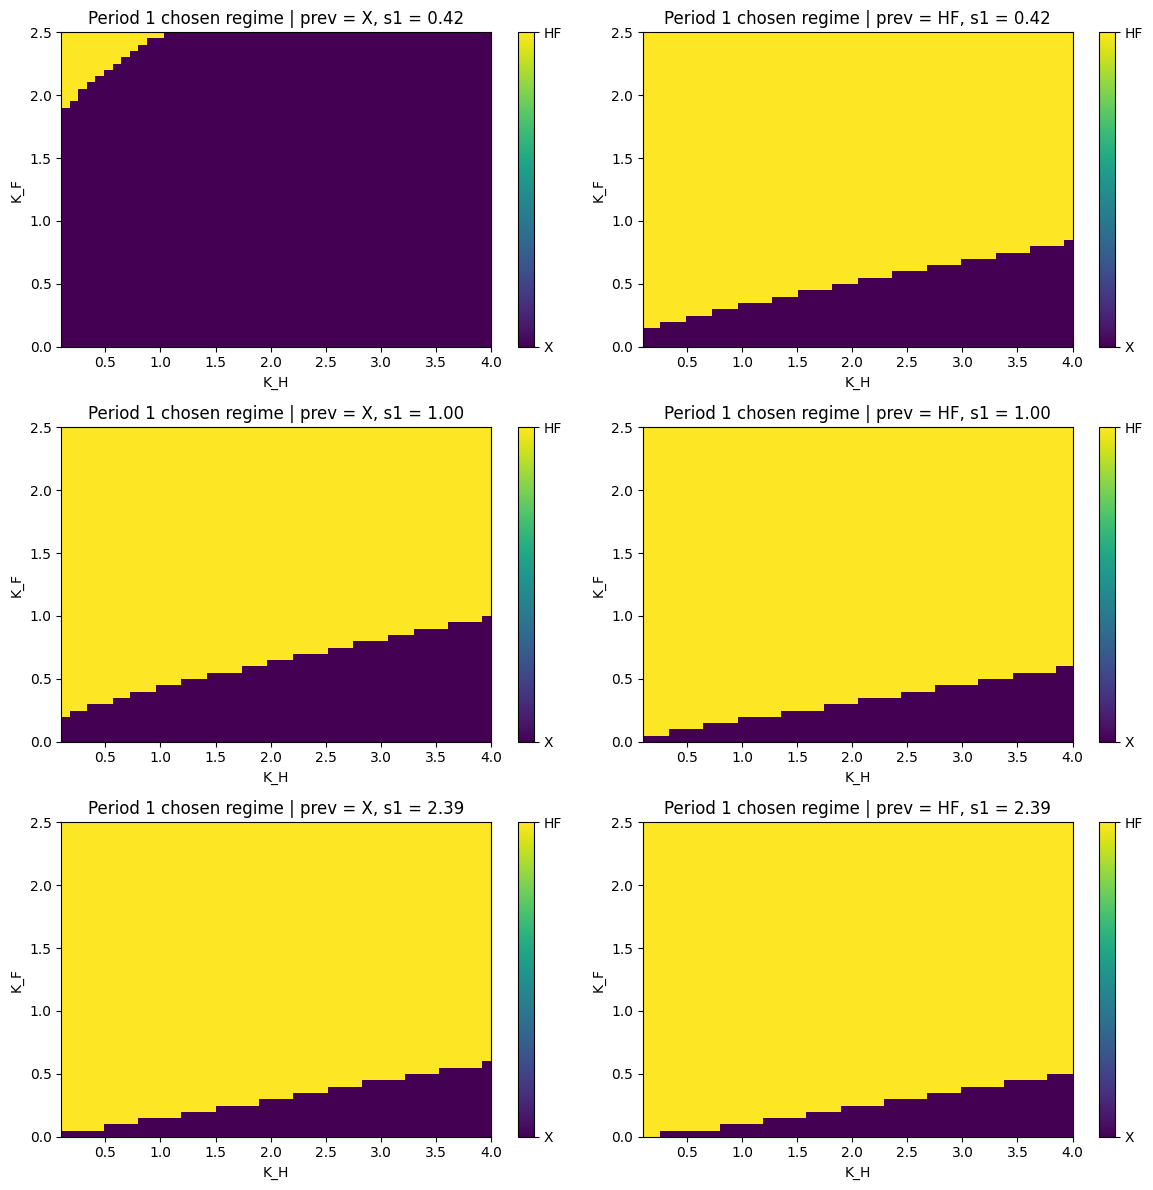

,region,share_of_grid
0,X -> X,0.2520
1,X -> HF,0.7480
2,HF -> HF,0.8708
3,HF -> X,0.1292
4,hysteresis,0.1228


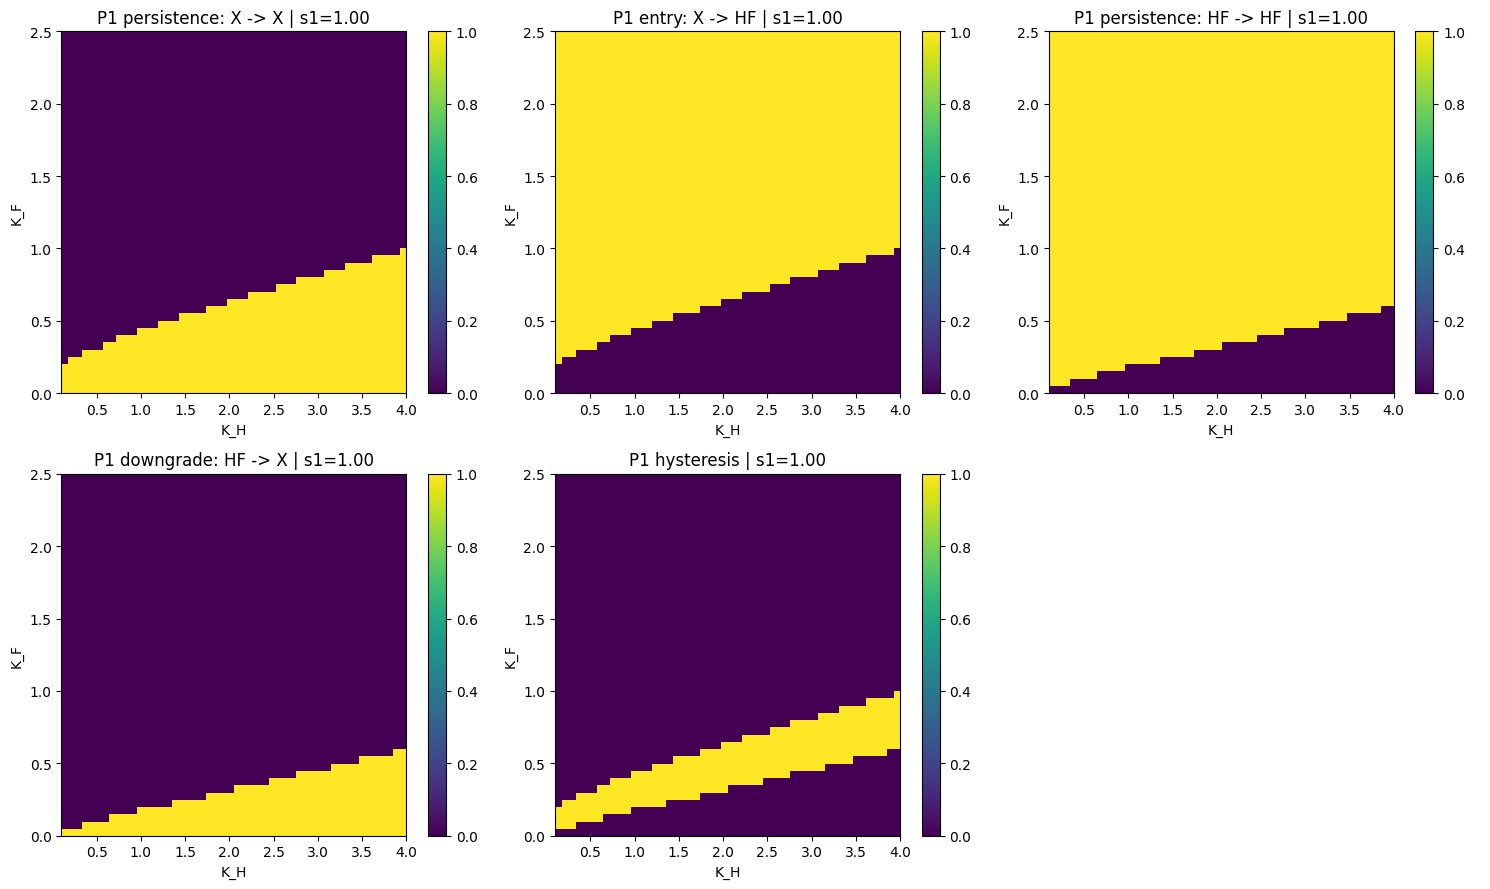

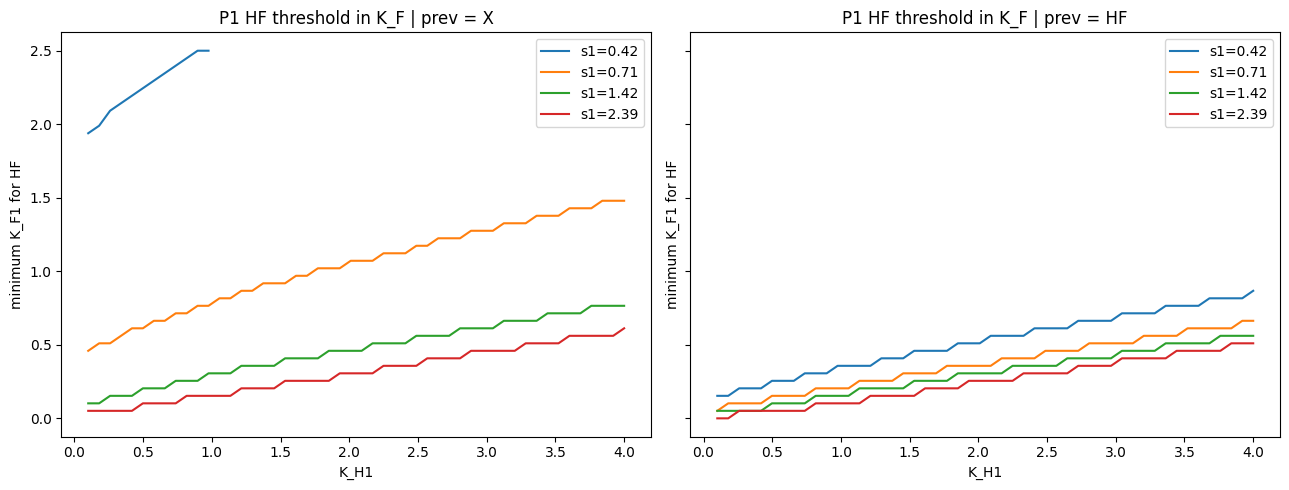

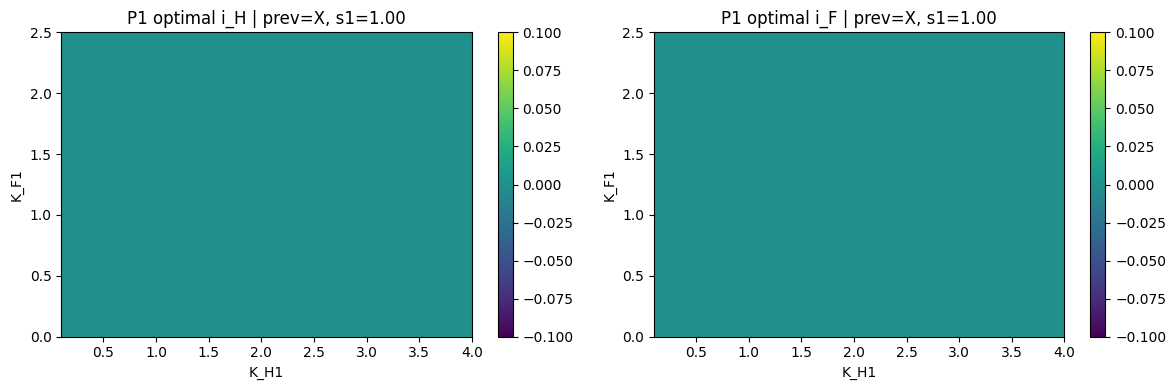

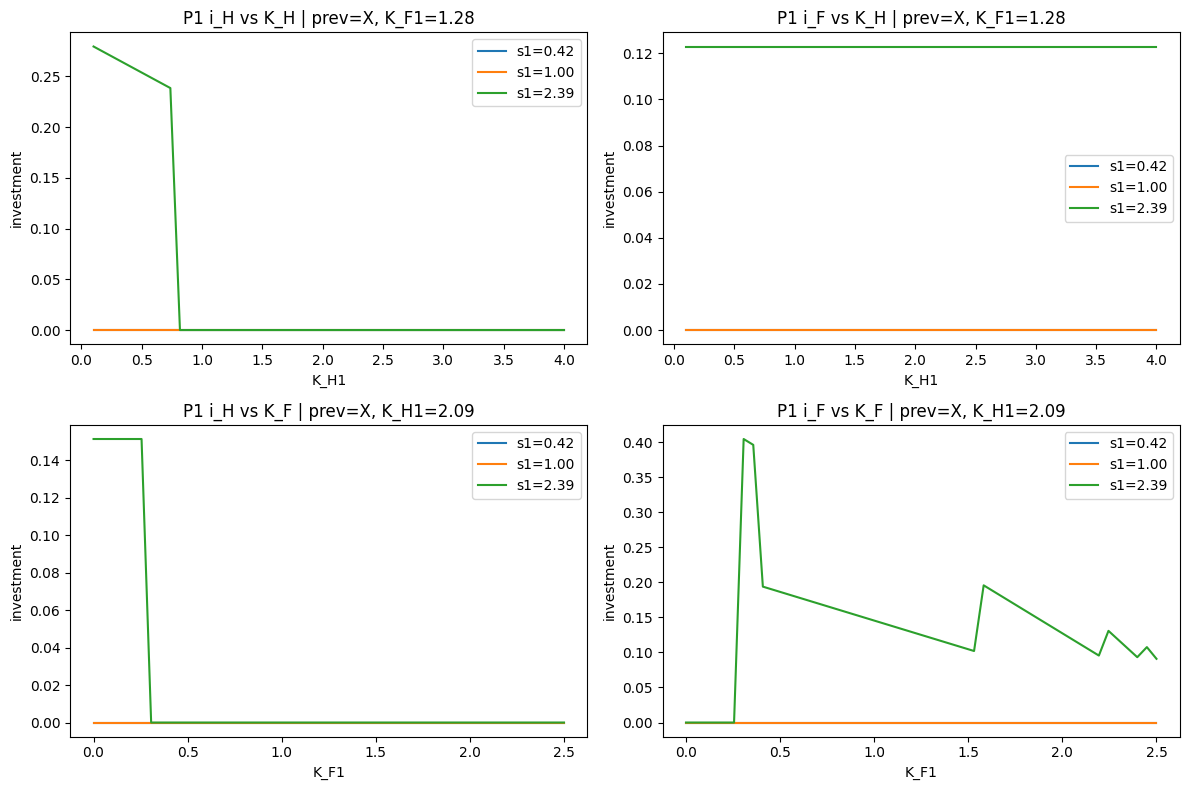

,s_idx,s,share_X_to_X,share_X_to_HF,share_HF_to_HF,share_HF_to_X,share_hysteresis,mean_iH_prev_X,mean_iF_prev_X,mean_iH_prev_HF,mean_iF_prev_HF
0,0,0.418712,0.9724,0.0276,0.7960,0.2040,0.7684,0.000000,0.000000,0.000000,0.000000
1,1,0.498348,0.7812,0.2188,0.8224,0.1776,0.6036,0.000000,0.000000,0.000000,0.000000
2,2,0.593129,0.5524,0.4476,0.8412,0.1588,0.3936,0.000000,0.000000,0.000000,0.000000
3,3,0.705937,0.4072,0.5928,0.8544,0.1456,0.2616,0.000000,0.000000,0.000000,0.000000
4,4,0.840201,0.3144,0.6856,0.8640,0.1360,0.1784,0.000000,0.000000,0.000000,0.000000
5,5,1.000000,0.2520,0.7480,0.8708,0.1292,0.1228,0.000000,0.000000,0.000000,0.000000
6,6,1.190192,0.2108,0.7892,0.8760,0.1240,0.0868,0.000000,0.000000,0.000000,0.000268
7,7,1.416556,0.1816,0.8184,0.8800,0.1200,0.0616,0.000223,0.002187,0.000112,0.005518
8,8,1.685973,0.1560,0.8440,0.8880,0.1120,0.0440,0.000964,0.033264,0.000538,0.041958
9,9,2.006631,0.1348,0.8652,0.8960,0.1040,0.0308,0.019359,0.097477,0.018125,0.103644


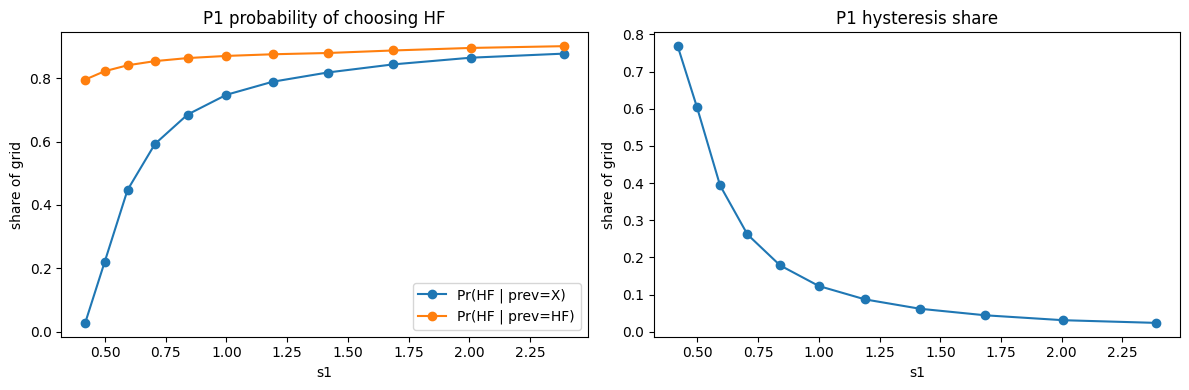

In [69]:
# %% [markdown]
# ## Period 1
# ### 3.1 Policy maps

# %%
fig, axes = plt.subplots(len(selected_s_idx), 2, figsize=(12, 4 * len(selected_s_idx)))

for r, k in enumerate(selected_s_idx):
    s1_val = float(s_grid[k])

    policy1_x = grid_sol_p1["policy_mode"][pm_x, :, :, k]
    policy1_hf = grid_sol_p1["policy_mode"][pm_hf, :, :, k]

    plot_policy_map(
        axes[r, 0], policy1_x, KH_grid, KF_grid, cfg,
        title=f"Period 1 chosen regime | prev = X, s1 = {s1_val:.2f}"
    )
    plot_policy_map(
        axes[r, 1], policy1_hf, KH_grid, KF_grid, cfg,
        title=f"Period 1 chosen regime | prev = HF, s1 = {s1_val:.2f}"
    )

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.2 Persistence, entry, and hysteresis at period 1

# %%
s1_val_mid = float(s_grid[s_idx_mid])

policy1_x_mid = grid_sol_p1["policy_mode"][pm_x, :, :, s_idx_mid]
policy1_hf_mid = grid_sol_p1["policy_mode"][pm_hf, :, :, s_idx_mid]

stay_x1 = (policy1_x_mid == pm_x)
switch_x_to_hf1 = (policy1_x_mid == pm_hf)
stay_hf1 = (policy1_hf_mid == pm_hf)
switch_hf_to_x1 = (policy1_hf_mid == pm_x)
hysteresis1 = stay_x1 & stay_hf1

share_table_p1 = pd.DataFrame({
    "region": ["X -> X", "X -> HF", "HF -> HF", "HF -> X", "hysteresis"],
    "share_of_grid": [
        stay_x1.mean(),
        switch_x_to_hf1.mean(),
        stay_hf1.mean(),
        switch_hf_to_x1.mean(),
        hysteresis1.mean(),
    ]
})
display(share_table_p1)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_binary_map(axes[0, 0], stay_x1, KH_grid, KF_grid, f"P1 persistence: X -> X | s1={s1_val_mid:.2f}")
plot_binary_map(axes[0, 1], switch_x_to_hf1, KH_grid, KF_grid, f"P1 entry: X -> HF | s1={s1_val_mid:.2f}")
plot_binary_map(axes[0, 2], stay_hf1, KH_grid, KF_grid, f"P1 persistence: HF -> HF | s1={s1_val_mid:.2f}")
plot_binary_map(axes[1, 0], switch_hf_to_x1, KH_grid, KF_grid, f"P1 downgrade: HF -> X | s1={s1_val_mid:.2f}")
plot_binary_map(axes[1, 1], hysteresis1, KH_grid, KF_grid, f"P1 hysteresis | s1={s1_val_mid:.2f}")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.3 HF threshold in K_F at period 1

# %%
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

for k in selected_s_idx_thr:
    s1_val = float(s_grid[k])

    policy1_x = grid_sol_p1["policy_mode"][pm_x, :, :, k]
    policy1_hf = grid_sol_p1["policy_mode"][pm_hf, :, :, k]

    thr_x = kf_threshold_for_hf(policy1_x, KF_grid, pm_hf)
    thr_hf = kf_threshold_for_hf(policy1_hf, KF_grid, pm_hf)

    axes[0].plot(KH_grid, thr_x, label=f"s1={s1_val:.2f}")
    axes[1].plot(KH_grid, thr_hf, label=f"s1={s1_val:.2f}")

axes[0].set_title("P1 HF threshold in K_F | prev = X")
axes[1].set_title("P1 HF threshold in K_F | prev = HF")
for ax in axes:
    ax.set_xlabel("K_H1")
    ax.set_ylabel("minimum K_F1 for HF")
    ax.legend()
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.4 Investment maps at period 1

# %%
iH1_x_mid = grid_sol_p1["iH_star"][pm_x, :, :, s_idx_mid]
iF1_x_mid = grid_sol_p1["iF_star"][pm_x, :, :, s_idx_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(
    iH1_x_mid.T, origin="lower", aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
axes[0].set_xlabel("K_H1")
axes[0].set_ylabel("K_F1")
axes[0].set_title(f"P1 optimal i_H | prev=X, s1={s1_val_mid:.2f}")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    iF1_x_mid.T, origin="lower", aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
axes[1].set_xlabel("K_H1")
axes[1].set_ylabel("K_F1")
axes[1].set_title(f"P1 optimal i_F | prev=X, s1={s1_val_mid:.2f}")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.5 Investment responses at period 1 along K_H and K_F slices

# %%
KF1_fixed = float(KF_grid[j_mid])
KH1_fixed = float(KH_grid[i_mid])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

for k in selected_s_idx:
    s1_val = float(s_grid[k])
    label = f"s1={s1_val:.2f}"

    axes[0, 0].plot(KH_grid, grid_sol_p1["iH_star"][pm_x, :, j_mid, k], label=label)
    axes[0, 1].plot(KH_grid, grid_sol_p1["iF_star"][pm_x, :, j_mid, k], label=label)

    axes[1, 0].plot(KF_grid, grid_sol_p1["iH_star"][pm_x, i_mid, :, k], label=label)
    axes[1, 1].plot(KF_grid, grid_sol_p1["iF_star"][pm_x, i_mid, :, k], label=label)

axes[0, 0].set_title(f"P1 i_H vs K_H | prev=X, K_F1={KF1_fixed:.2f}")
axes[0, 1].set_title(f"P1 i_F vs K_H | prev=X, K_F1={KF1_fixed:.2f}")
axes[1, 0].set_title(f"P1 i_H vs K_F | prev=X, K_H1={KH1_fixed:.2f}")
axes[1, 1].set_title(f"P1 i_F vs K_F | prev=X, K_H1={KH1_fixed:.2f}")

axes[0, 0].set_xlabel("K_H1"); axes[0, 1].set_xlabel("K_H1")
axes[1, 0].set_xlabel("K_F1"); axes[1, 1].set_xlabel("K_F1")
for ax in axes.ravel():
    ax.set_ylabel("investment")
    ax.legend()

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 3.6 Transition shares over productivity at period 1

# %%
summary_p1 = period_transition_summary(grid_sol_p1, pm_x, pm_hf, s_grid)
display(summary_p1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary_p1["s"], summary_p1["share_X_to_HF"], marker="o", label="Pr(HF | prev=X)")
axes[0].plot(summary_p1["s"], summary_p1["share_HF_to_HF"], marker="o", label="Pr(HF | prev=HF)")
axes[0].set_xlabel("s1")
axes[0].set_ylabel("share of grid")
axes[0].set_title("P1 probability of choosing HF")
axes[0].legend()

axes[1].plot(summary_p1["s"], summary_p1["share_hysteresis"], marker="o")
axes[1].set_xlabel("s1")
axes[1].set_ylabel("share of grid")
axes[1].set_title("P1 hysteresis share")

plt.tight_layout()
plt.show()

## Period 2

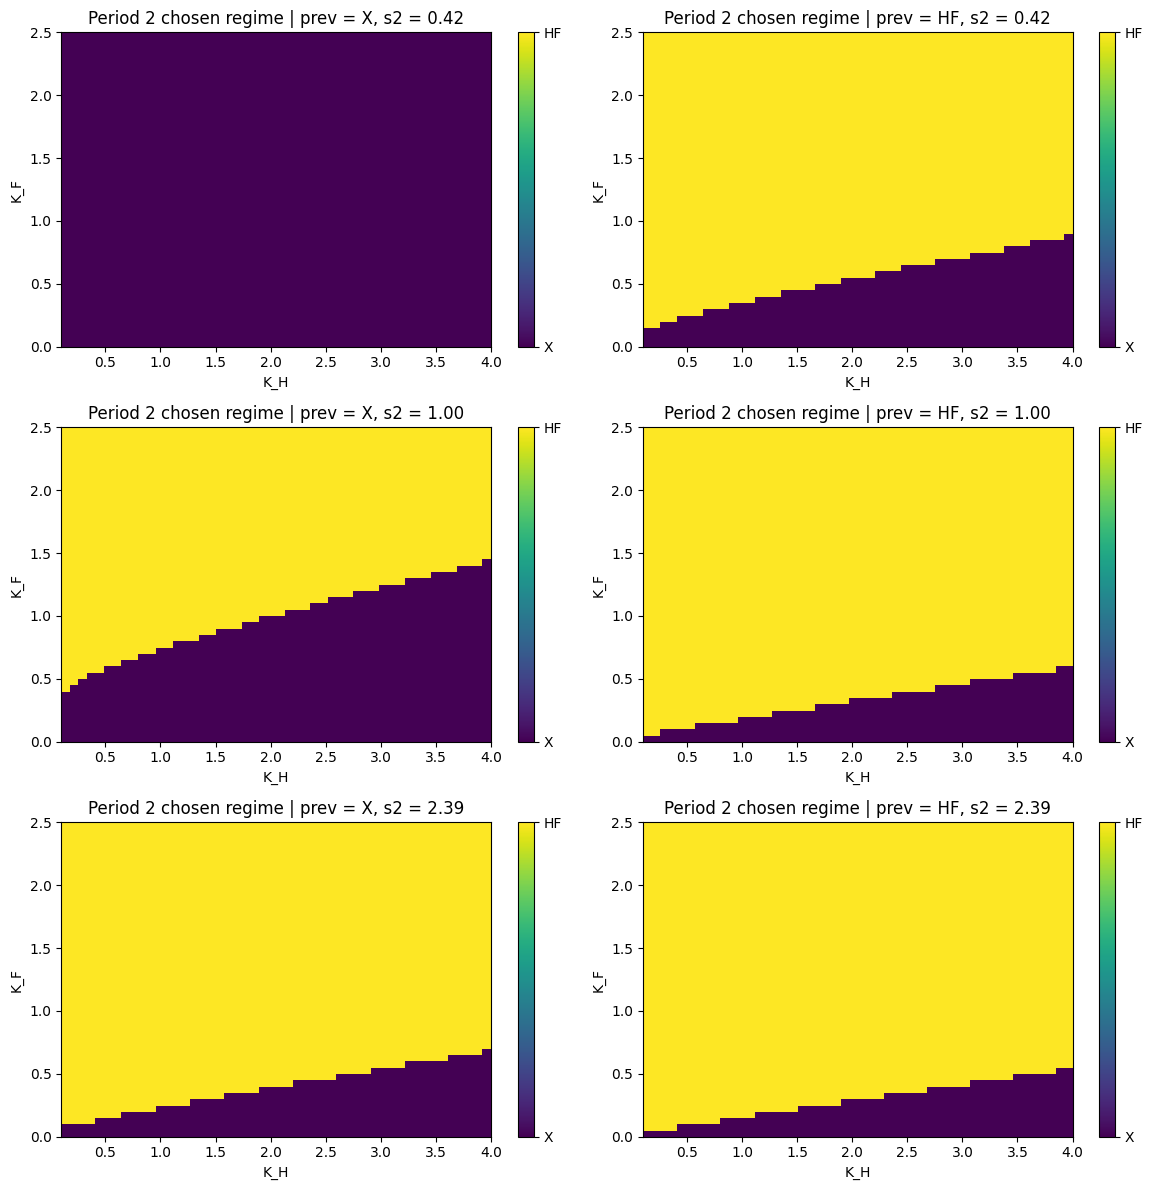

,region,share_of_grid
0,X -> X,0.3944
1,X -> HF,0.6056
2,HF -> HF,0.8680
3,HF -> X,0.1320
4,hysteresis,0.2624


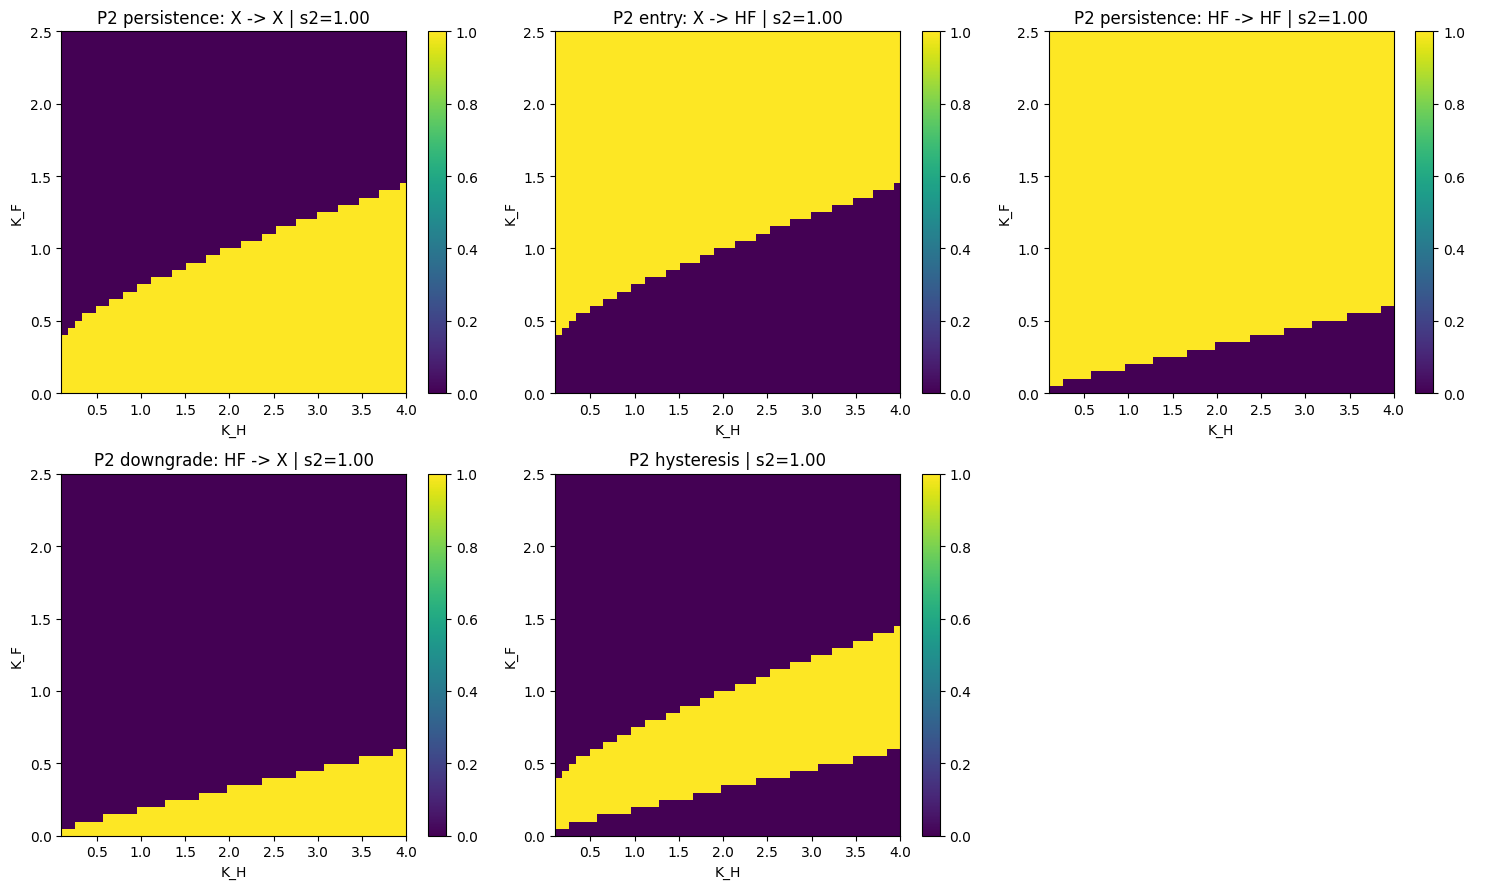

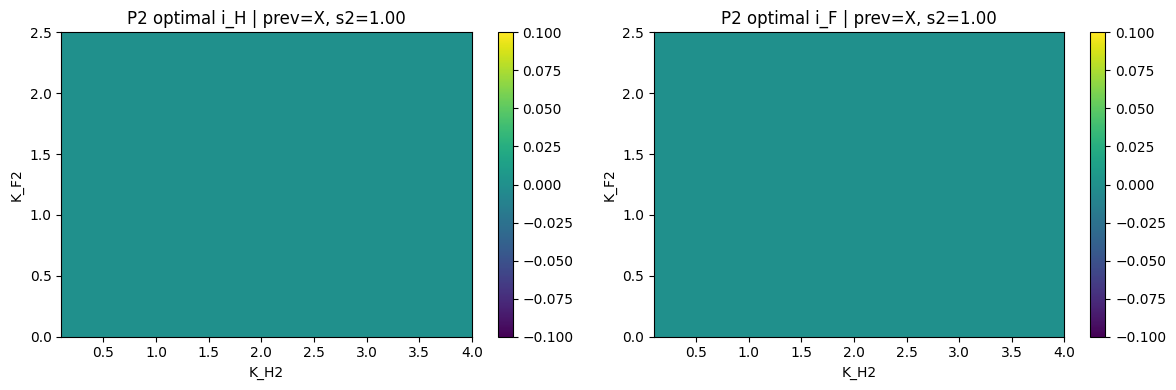

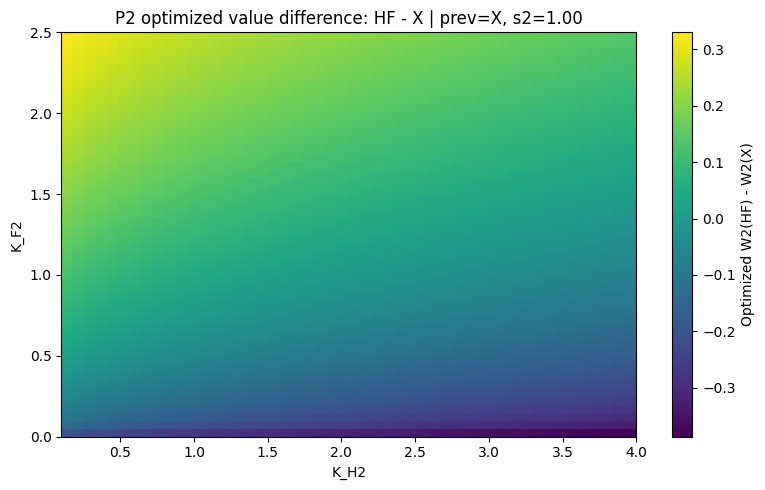

,s_idx,s,share_X_to_X,share_X_to_HF,share_HF_to_HF,share_HF_to_X,share_hysteresis,mean_iH_prev_X,mean_iF_prev_X,mean_iH_prev_HF,mean_iF_prev_HF
0,0,0.418712,1.0000,0.0000,0.7840,0.2160,0.7840,0.0,0.0,0.0,0.0
1,1,0.498348,1.0000,0.0000,0.8140,0.1860,0.8140,0.0,0.0,0.0,0.0
2,2,0.593129,0.9764,0.0236,0.8364,0.1636,0.8128,0.0,0.0,0.0,0.0
3,3,0.705937,0.7772,0.2228,0.8500,0.1500,0.6272,0.0,0.0,0.0,0.0
4,4,0.840201,0.5412,0.4588,0.8612,0.1388,0.4024,0.0,0.0,0.0,0.0
5,5,1.000000,0.3944,0.6056,0.8680,0.1320,0.2624,0.0,0.0,0.0,0.0
6,6,1.190192,0.3020,0.6980,0.8736,0.1264,0.1756,0.0,0.0,0.0,0.0
7,7,1.416556,0.2412,0.7588,0.8772,0.1228,0.1184,0.0,0.0,0.0,0.0
8,8,1.685973,0.2024,0.7976,0.8796,0.1204,0.0820,0.0,0.0,0.0,0.0
9,9,2.006631,0.1756,0.8244,0.8812,0.1188,0.0568,0.0,0.0,0.0,0.0


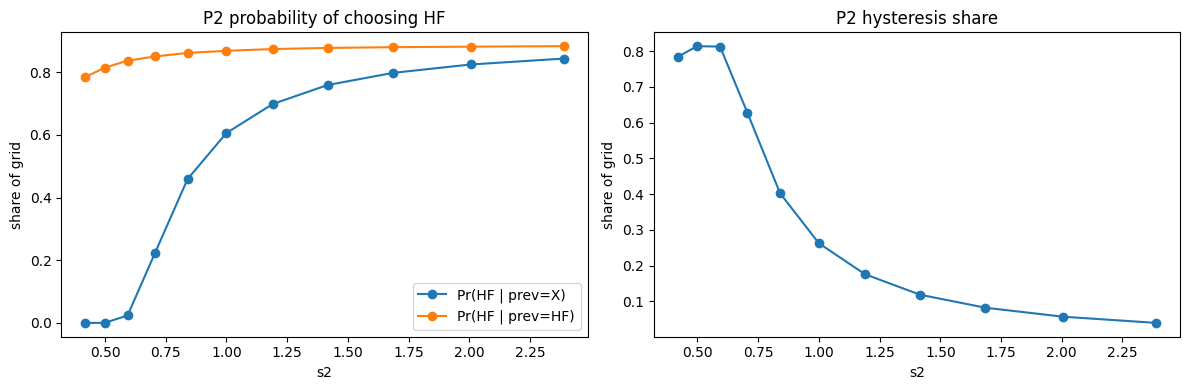

In [70]:
# %% [markdown]
# ## Period 2
# ### 4.1 Policy maps

# %%
fig, axes = plt.subplots(len(selected_s_idx), 2, figsize=(12, 4 * len(selected_s_idx)))

for r, k in enumerate(selected_s_idx):
    s2_val = float(s_grid[k])

    policy2_x = grid_sol_p2["policy_mode"][pm_x, :, :, k]
    policy2_hf = grid_sol_p2["policy_mode"][pm_hf, :, :, k]

    plot_policy_map(
        axes[r, 0], policy2_x, KH_grid, KF_grid, cfg,
        title=f"Period 2 chosen regime | prev = X, s2 = {s2_val:.2f}"
    )
    plot_policy_map(
        axes[r, 1], policy2_hf, KH_grid, KF_grid, cfg,
        title=f"Period 2 chosen regime | prev = HF, s2 = {s2_val:.2f}"
    )

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4.2 Persistence, entry, and hysteresis at period 2

# %%
s2_val_mid = float(s_grid[s_idx_mid])

policy2_x_mid = grid_sol_p2["policy_mode"][pm_x, :, :, s_idx_mid]
policy2_hf_mid = grid_sol_p2["policy_mode"][pm_hf, :, :, s_idx_mid]

stay_x2 = (policy2_x_mid == pm_x)
switch_x_to_hf2 = (policy2_x_mid == pm_hf)
stay_hf2 = (policy2_hf_mid == pm_hf)
switch_hf_to_x2 = (policy2_hf_mid == pm_x)
hysteresis2 = stay_x2 & stay_hf2

share_table_p2 = pd.DataFrame({
    "region": ["X -> X", "X -> HF", "HF -> HF", "HF -> X", "hysteresis"],
    "share_of_grid": [
        stay_x2.mean(),
        switch_x_to_hf2.mean(),
        stay_hf2.mean(),
        switch_hf_to_x2.mean(),
        hysteresis2.mean(),
    ]
})
display(share_table_p2)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
plot_binary_map(axes[0, 0], stay_x2, KH_grid, KF_grid, f"P2 persistence: X -> X | s2={s2_val_mid:.2f}")
plot_binary_map(axes[0, 1], switch_x_to_hf2, KH_grid, KF_grid, f"P2 entry: X -> HF | s2={s2_val_mid:.2f}")
plot_binary_map(axes[0, 2], stay_hf2, KH_grid, KF_grid, f"P2 persistence: HF -> HF | s2={s2_val_mid:.2f}")
plot_binary_map(axes[1, 0], switch_hf_to_x2, KH_grid, KF_grid, f"P2 downgrade: HF -> X | s2={s2_val_mid:.2f}")
plot_binary_map(axes[1, 1], hysteresis2, KH_grid, KF_grid, f"P2 hysteresis | s2={s2_val_mid:.2f}")
axes[1, 2].axis("off")
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4.3 Investment maps at period 2

# %%
iH2_x_mid = grid_sol_p2["iH_star"][pm_x, :, :, s_idx_mid]
iF2_x_mid = grid_sol_p2["iF_star"][pm_x, :, :, s_idx_mid]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(
    iH2_x_mid.T, origin="lower", aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
axes[0].set_xlabel("K_H2")
axes[0].set_ylabel("K_F2")
axes[0].set_title(f"P2 optimal i_H | prev=X, s2={s2_val_mid:.2f}")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(
    iF2_x_mid.T, origin="lower", aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
axes[1].set_xlabel("K_H2")
axes[1].set_ylabel("K_F2")
axes[1].set_title(f"P2 optimal i_F | prev=X, s2={s2_val_mid:.2f}")
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4.4 Period-2 optimized value difference: HF - X

# %%
Wdiff_hf_x_t2 = np.empty((len(KH_grid), len(KF_grid)))

for i, KH in enumerate(KH_grid):
    for j, KF in enumerate(KF_grid):
        bx = solve_period2_branch(
            mode="X",
            prev_mode="X",
            KH=KH,
            KF=KF,
            s=s2_val_mid,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            n_search_iH=41,
            n_search_iF=31,
        )
        bhf = solve_period2_branch(
            mode="HF",
            prev_mode="X",
            KH=KH,
            KF=KF,
            s=s2_val_mid,
            p=p,
            KH_grid=KH_grid,
            KF_grid=KF_grid,
            n_search_iH=41,
            n_search_iF=31,
        )
        Wdiff_hf_x_t2[i, j] = bhf["value"] - bx["value"]

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(
    Wdiff_hf_x_t2.T,
    origin="lower",
    aspect="auto",
    extent=[KH_grid[0], KH_grid[-1], KF_grid[0], KF_grid[-1]]
)
fig.colorbar(im, ax=ax, label="Optimized W2(HF) - W2(X)")
ax.set_xlabel("K_H2")
ax.set_ylabel("K_F2")
ax.set_title(f"P2 optimized value difference: HF - X | prev=X, s2={s2_val_mid:.2f}")
plt.tight_layout()
plt.show()

# %% [markdown]
# ### 4.5 Transition shares over productivity at period 2

# %%
summary_p2 = period_transition_summary(grid_sol_p2, pm_x, pm_hf, s_grid)
display(summary_p2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(summary_p2["s"], summary_p2["share_X_to_HF"], marker="o", label="Pr(HF | prev=X)")
axes[0].plot(summary_p2["s"], summary_p2["share_HF_to_HF"], marker="o", label="Pr(HF | prev=HF)")
axes[0].set_xlabel("s2")
axes[0].set_ylabel("share of grid")
axes[0].set_title("P2 probability of choosing HF")
axes[0].legend()

axes[1].plot(summary_p2["s"], summary_p2["share_hysteresis"], marker="o")
axes[1].set_xlabel("s2")
axes[1].set_ylabel("share of grid")
axes[1].set_title("P2 hysteresis share")

plt.tight_layout()
plt.show()

## SIMULATION

Number of firms simulated: 5000


,firm_id,m_minus1,KH0,KF0,s0_idx,s0,mode0,iH0,iF0,KH1,...,s2,mode2,iH2,iF2,KH3,KF3,scrap_value_t3,transition_m1_0,transition_01,transition_12
0,0,X,0.100000,0.051020,5,1.000000,X,0.0,0.0,0.090000,...,1.190192,X,0.0,0.0,0.072900,0.037194,0.044038,X -> X,X -> X,X -> X
1,1,X,2.806122,1.530612,4,0.840201,HF,0.0,0.0,2.525510,...,1.000000,HF,0.0,0.0,2.045663,1.115816,1.264592,X -> HF,HF -> HF,HF -> HF
2,2,X,2.408163,1.071429,4,0.840201,HF,0.0,0.0,2.167347,...,1.190192,HF,0.0,0.0,1.755551,0.781071,1.014649,X -> HF,HF -> HF,HF -> HF
3,3,X,0.259184,0.357143,5,1.000000,HF,0.0,0.0,0.233265,...,1.000000,HF,0.0,0.0,0.188945,0.260357,0.179721,X -> HF,HF -> HF,HF -> HF
4,4,X,3.681633,0.255102,7,1.416556,X,0.0,0.0,3.313469,...,1.416556,X,0.0,0.0,2.683910,0.185969,1.147952,X -> X,X -> X,X -> X



Counts: transition_m1_0


,count
transition_m1_0,
X -> HF,3877
X -> X,1123


Shares: transition_m1_0


...

,s0,KH0,KF0,iH0,iF0
transition_m1_0,,,,,
X -> HF,1.054,1.907,1.501,0.005,0.029
X -> X,0.954,2.469,0.331,0.005,0.000


Mean states and investments by mode0 -> mode1


,s1,KH1,KF1,iH1,iF1
transition_01,,,,,
HF -> HF,1.051,1.721,1.380,0.0,0.002
X -> HF,1.175,2.048,0.719,0.0,0.060
X -> X,0.962,2.228,0.297,0.0,0.000


Mean states and investments by mode1 -> mode2


,s2,KH2,KF2,iH2,iF2
transition_12,,,,,
HF -> HF,1.053,1.549,1.244,0.0,0.0
X -> HF,1.417,0.274,0.248,0.0,0.0
X -> X,0.976,2.007,0.267,0.0,0.0


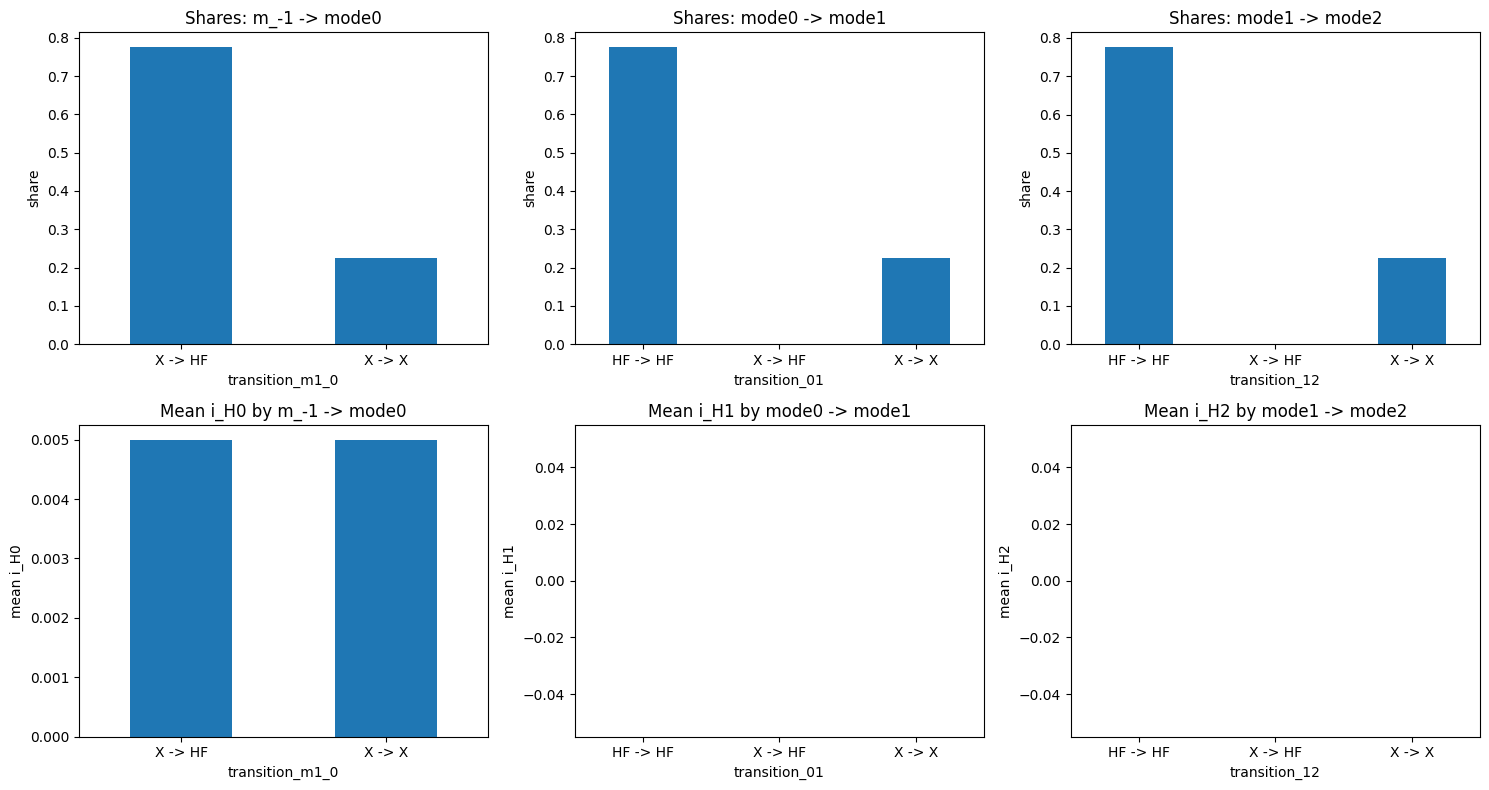

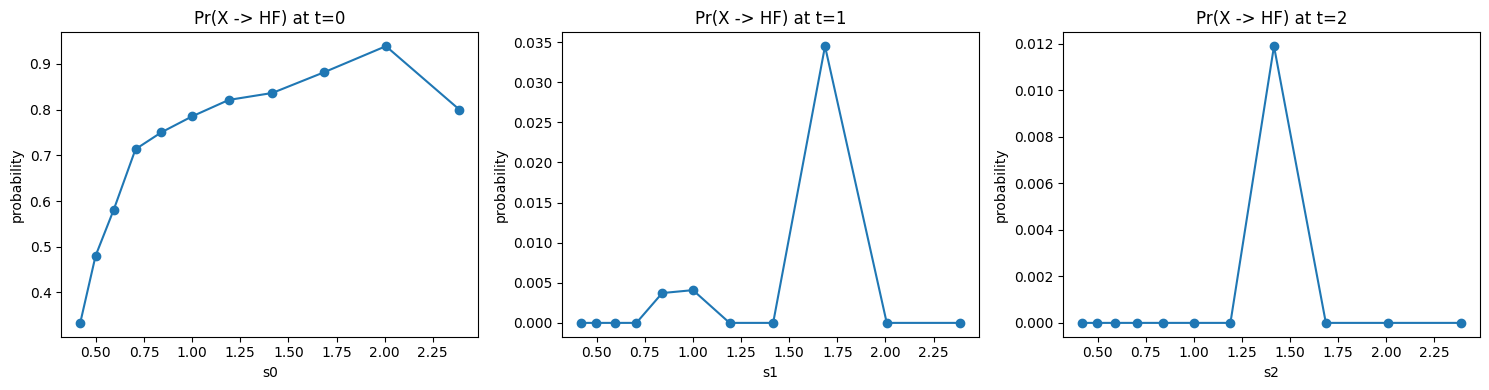

In [71]:
# %% [markdown]
# ## 3-period simulation
# ### 5.1 Fast simulation using solved policy grids
# 
# Initial inherited regime is fixed at m_{-1}=X.

# %%
def simulate_firms_3periods_from_policy_grids(
    n_firms: int,
    KH_grid: np.ndarray,
    KF_grid: np.ndarray,
    s_grid: np.ndarray,
    P: np.ndarray,
    grid_sol_p0: Dict[str, np.ndarray],
    grid_sol_p1: Dict[str, np.ndarray],
    grid_sol_p2: Dict[str, np.ndarray],
    p: ModelParams,
    cfg: RegimeConfig,
    seed: int = 123,
    stationary_probs: np.ndarray | None = None,
    initial_prev_mode: str = "X",
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)

    if stationary_probs is None:
        stationary_probs = stationary_distribution(P)

    KH0_init = rng.choice(KH_grid, size=n_firms)
    KF0_init = rng.choice(KF_grid, size=n_firms)
    s0_idx_init = rng.choice(np.arange(len(s_grid)), size=n_firms, p=stationary_probs)

    rows = []
    pm_init = cfg.mode_to_index[initial_prev_mode]

    for firm_id in range(n_firms):
        KH0 = float(KH0_init[firm_id])
        KF0 = float(KF0_init[firm_id])
        s0_idx = int(s0_idx_init[firm_id])

        i0 = nearest_index(KH_grid, KH0)
        j0 = nearest_index(KF_grid, KF0)

        mode0_idx = int(grid_sol_p0["policy_mode"][pm_init, i0, j0, s0_idx])
        mode0 = decode_mode(mode0_idx, cfg)
        iH0 = float(grid_sol_p0["iH_star"][pm_init, i0, j0, s0_idx])
        iF0 = float(grid_sol_p0["iF_star"][pm_init, i0, j0, s0_idx])

        KH1 = float(next_capital(KH0, iH0, p.delta))
        KF1 = float(next_capital(KF0, iF0, p.delta))

        s1_idx = int(rng.choice(np.arange(len(s_grid)), p=P[s0_idx, :]))
        i1 = nearest_index(KH_grid, KH1)
        j1 = nearest_index(KF_grid, KF1)
        pm1 = cfg.mode_to_index[mode0]

        mode1_idx = int(grid_sol_p1["policy_mode"][pm1, i1, j1, s1_idx])
        mode1 = decode_mode(mode1_idx, cfg)
        iH1 = float(grid_sol_p1["iH_star"][pm1, i1, j1, s1_idx])
        iF1 = float(grid_sol_p1["iF_star"][pm1, i1, j1, s1_idx])

        KH2 = float(next_capital(KH1, iH1, p.delta))
        KF2 = float(next_capital(KF1, iF1, p.delta))

        s2_idx = int(rng.choice(np.arange(len(s_grid)), p=P[s1_idx, :]))
        i2 = nearest_index(KH_grid, KH2)
        j2 = nearest_index(KF_grid, KF2)
        pm2 = cfg.mode_to_index[mode1]

        mode2_idx = int(grid_sol_p2["policy_mode"][pm2, i2, j2, s2_idx])
        mode2 = decode_mode(mode2_idx, cfg)
        iH2 = float(grid_sol_p2["iH_star"][pm2, i2, j2, s2_idx])
        iF2 = float(grid_sol_p2["iF_star"][pm2, i2, j2, s2_idx])

        KH3 = float(next_capital(KH2, iH2, p.delta))
        KF3 = float(next_capital(KF2, iF2, p.delta))
        scrap = terminal_value(KH3, KF3, 0.0, p)

        rows.append({
            "firm_id": firm_id,
            "m_minus1": initial_prev_mode,

            "KH0": KH0, "KF0": KF0, "s0_idx": s0_idx, "s0": float(s_grid[s0_idx]),
            "mode0": mode0, "iH0": iH0, "iF0": iF0,

            "KH1": KH1, "KF1": KF1, "s1_idx": s1_idx, "s1": float(s_grid[s1_idx]),
            "mode1": mode1, "iH1": iH1, "iF1": iF1,

            "KH2": KH2, "KF2": KF2, "s2_idx": s2_idx, "s2": float(s_grid[s2_idx]),
            "mode2": mode2, "iH2": iH2, "iF2": iF2,

            "KH3": KH3, "KF3": KF3, "scrap_value_t3": scrap,
        })

    df = pd.DataFrame(rows)
    df["transition_m1_0"] = df["m_minus1"] + " -> " + df["mode0"]
    df["transition_01"] = df["mode0"] + " -> " + df["mode1"]
    df["transition_12"] = df["mode1"] + " -> " + df["mode2"]
    return df

# %% [markdown]
# ### 5.2 Simulate firms

# %%
n_firms = 5000
pi_stat = stationary_distribution(P)

sim3_df = simulate_firms_3periods_from_policy_grids(
    n_firms=n_firms,
    KH_grid=KH_grid,
    KF_grid=KF_grid,
    s_grid=s_grid,
    P=P,
    grid_sol_p0=grid_sol_p0,
    grid_sol_p1=grid_sol_p1,
    grid_sol_p2=grid_sol_p2,
    p=p,
    cfg=cfg,
    seed=123,
    stationary_probs=pi_stat,
    initial_prev_mode="X",
)

print(f"Number of firms simulated: {len(sim3_df)}")
display(sim3_df.head())

# %% [markdown]
# ### 5.3 Transition tables across periods

# %%
for col in ["transition_m1_0", "transition_01", "transition_12"]:
    print(f"\nCounts: {col}")
    display(sim3_df[col].value_counts().sort_index().to_frame("count"))

    print(f"Shares: {col}")
    display(sim3_df[col].value_counts(normalize=True).sort_index().to_frame("share"))

# %% [markdown]
# ### 5.4 Transition matrices and mean investments

# %%
mat_m10 = pd.crosstab(sim3_df["m_minus1"], sim3_df["mode0"], normalize="index").round(3)
mat_01 = pd.crosstab(sim3_df["mode0"], sim3_df["mode1"], normalize="index").round(3)
mat_12 = pd.crosstab(sim3_df["mode1"], sim3_df["mode2"], normalize="index").round(3)

print("Row-normalized matrix: m_-1 -> mode0")
display(mat_m10)

print("Row-normalized matrix: mode0 -> mode1")
display(mat_01)

print("Row-normalized matrix: mode1 -> mode2")
display(mat_12)

mean_by_m10 = sim3_df.groupby("transition_m1_0")[["s0", "KH0", "KF0", "iH0", "iF0"]].mean().round(3)
mean_by_01 = sim3_df.groupby("transition_01")[["s1", "KH1", "KF1", "iH1", "iF1"]].mean().round(3)
mean_by_12 = sim3_df.groupby("transition_12")[["s2", "KH2", "KF2", "iH2", "iF2"]].mean().round(3)

print("Mean states and investments by m_-1 -> mode0")
display(mean_by_m10)

print("Mean states and investments by mode0 -> mode1")
display(mean_by_01)

print("Mean states and investments by mode1 -> mode2")
display(mean_by_12)

# %% [markdown]
# ### 5.5 Transition plots

# %%
shares_m10 = sim3_df["transition_m1_0"].value_counts(normalize=True).sort_index()
shares_01 = sim3_df["transition_01"].value_counts(normalize=True).sort_index()
shares_12 = sim3_df["transition_12"].value_counts(normalize=True).sort_index()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

shares_m10.plot(kind="bar", ax=axes[0, 0], rot=0)
axes[0, 0].set_title("Shares: m_-1 -> mode0")
axes[0, 0].set_ylabel("share")

shares_01.plot(kind="bar", ax=axes[0, 1], rot=0)
axes[0, 1].set_title("Shares: mode0 -> mode1")
axes[0, 1].set_ylabel("share")

shares_12.plot(kind="bar", ax=axes[0, 2], rot=0)
axes[0, 2].set_title("Shares: mode1 -> mode2")
axes[0, 2].set_ylabel("share")

mean_by_m10["iH0"].plot(kind="bar", ax=axes[1, 0], rot=0)
axes[1, 0].set_title("Mean i_H0 by m_-1 -> mode0")
axes[1, 0].set_ylabel("mean i_H0")

mean_by_01["iH1"].plot(kind="bar", ax=axes[1, 1], rot=0)
axes[1, 1].set_title("Mean i_H1 by mode0 -> mode1")
axes[1, 1].set_ylabel("mean i_H1")

mean_by_12["iH2"].plot(kind="bar", ax=axes[1, 2], rot=0)
axes[1, 2].set_title("Mean i_H2 by mode1 -> mode2")
axes[1, 2].set_ylabel("mean i_H2")

plt.tight_layout()
plt.show()

# %% [markdown]
# ### 5.6 Probability of X -> HF over time in the simulation

# %%
enter_hf_t0 = (
    sim3_df
    .groupby("s0_idx")
    .agg(
        prob_enter_HF=("mode0", lambda x: np.mean(x == "HF")),
        mean_iH0=("iH0", "mean"),
        mean_iF0=("iF0", "mean"),
        n=("firm_id", "size"),
    )
    .reset_index()
)
enter_hf_t0["s0"] = enter_hf_t0["s0_idx"].map(lambda k: float(s_grid[k]))

sim_x1 = sim3_df[sim3_df["mode0"] == "X"].copy()
enter_hf_t1 = (
    sim_x1
    .groupby("s1_idx")
    .agg(
        prob_enter_HF=("mode1", lambda x: np.mean(x == "HF")),
        mean_iH1=("iH1", "mean"),
        mean_iF1=("iF1", "mean"),
        n=("firm_id", "size"),
    )
    .reset_index()
)
enter_hf_t1["s1"] = enter_hf_t1["s1_idx"].map(lambda k: float(s_grid[k]))

sim_x2 = sim3_df[sim3_df["mode1"] == "X"].copy()
enter_hf_t2 = (
    sim_x2
    .groupby("s2_idx")
    .agg(
        prob_enter_HF=("mode2", lambda x: np.mean(x == "HF")),
        mean_iH2=("iH2", "mean"),
        mean_iF2=("iF2", "mean"),
        n=("firm_id", "size"),
    )
    .reset_index()
)
enter_hf_t2["s2"] = enter_hf_t2["s2_idx"].map(lambda k: float(s_grid[k]))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(enter_hf_t0["s0"], enter_hf_t0["prob_enter_HF"], marker="o")
axes[0].set_xlabel("s0")
axes[0].set_ylabel("probability")
axes[0].set_title("Pr(X -> HF) at t=0")

axes[1].plot(enter_hf_t1["s1"], enter_hf_t1["prob_enter_HF"], marker="o")
axes[1].set_xlabel("s1")
axes[1].set_ylabel("probability")
axes[1].set_title("Pr(X -> HF) at t=1")

axes[2].plot(enter_hf_t2["s2"], enter_hf_t2["prob_enter_HF"], marker="o")
axes[2].set_xlabel("s2")
axes[2].set_ylabel("probability")
axes[2].set_title("Pr(X -> HF) at t=2")

plt.tight_layout()
plt.show()